<a href="https://colab.research.google.com/github/Hassan-Himaz/GM1-Crutch/blob/main/more_stride_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    widgets = None
from IPython.display import display


In [ ]:
from pathlib import Path
from collections import deque

twopt_path = Path("hassan_2pt_left_crutch_right_damaged.csv")
threept_path = Path("hassan3pt_left_crutch_left_damaged.csv")
fourpt_path = Path("hassandata1_4pt_left_crutch_right_damaged.csv")
swing_path = Path("hassan_swing.csv")

DATASET_PATHS = {
    "swing": swing_path,
    "2pt": twopt_path,
    "3pt": threept_path,
    "4pt": fourpt_path,
}
DATASET_DIR = Path("Rig_tests_and_analysis")

# Force/r_diff tuning.
MAG_AXIS = "mz_uT"      # choose: mx_uT, my_uT, mz_uT, or mag_norm_uT
USE_ABS_FIELD = False    # use abs(axis) for single-axis force proxy
R0_MM = 25.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5

# Peak-relative release step detector tuning.
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 50
Z_ENTER = 2.0  # Increased from 1.96
RELEASE_FRACTION = 0.2
RELEASE_CONFIRM_MS = 50.0
REFRACTORY_MS = 50.0
POST_RELEASE_BASELINE_SAMPLES = BASELINE_WINDOW_SAMPLES
SUSTAINED_CUTOFF_S = 5.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
MIN_DURATION_S = 0.50
MIN_PEAK_FRAC_OF_MEDIAN = 0.30
MIN_AREA_FRAC_OF_MEDIAN = 0.30

RAW_CAPTURE_COLS = [
    "seq", "timestamp_ms",
    "ax_g", "ay_g", "az_g",
    "gx_dps", "gy_dps", "gz_dps",
    "roll_deg", "pitch_deg", "yaw_deg",
    "mx_uT", "my_uT", "mz_uT",
]

def resolve_capture_path(path):
    path = Path(path)
    if path.exists():
        return path
    analysis_path = DATASET_DIR / path
    if analysis_path.exists():
        return analysis_path
    return path

def load_hassan_capture_csv(path):
    path = resolve_capture_path(path)
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if parts[0] == "seq":
                continue
            if len(parts) != len(RAW_CAPTURE_COLS):
                continue
            try:
                rows.append([float(p) for p in parts])
            except ValueError:
                continue
    if not rows:
        return pd.DataFrame(), path
    df = pd.DataFrame(rows, columns=RAW_CAPTURE_COLS)
    df["seq"] = df["seq"].astype(int)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["accel_mag_g"] = np.sqrt(df["ax_g"]**2 + df["ay_g" ]**2 + df["az_g"]**2)
    df["gyro_mag_dps"] = np.sqrt(df["gx_dps"]**2 + df["gy_dps"]**2 + df["gz_dps"]**2)
    return df, path

def add_force_columns(df):
    df = df.copy()
    df["mag_norm_uT"] = np.sqrt(df["mx_uT"]**2 + df["my_uT"]**2 + df["mz_uT"]**2)
    field = df[MAG_AXIS]
    if USE_ABS_FIELD:
        field = field.abs()
    df["detector_signal_uT"] = field
    df["detector_signal_lpf_uT"] = field.ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    b0 = startup["detector_signal_lpf_uT"].mean()
    ratio = b0 / df["detector_signal_lpf_uT"]
    ratio = ratio.where((ratio > 0) & np.isfinite(ratio), np.nan)
    df["r_mm"] = R0_MM * np.cbrt(ratio)
    df["r_diff_mm"] = (R0_MM - df["r_mm"]).clip(lower=0.0)
    df["force_n"] = (FORCE_SLOPE * df["r_diff_mm" ] + FORCE_INTERCEPT).clip(lower=0.0)
    return df, b0

def event_area(df, start_s, release_s, baseline):
    event_df = df[(df["time_s"] >= start_s) & (df["time_s"] <= release_s)]
    if len(event_df) < 2:
        return 0.0
    y = (event_df["detector_signal_lpf_uT"] - baseline).clip(lower=0.0)
    return float(np.trapezoid(y, event_df["time_s"]))

def classify_rejections(events_df):
    if events_df.empty:
        events_df["accepted"] = []
        events_df["reject_reason"] = []
        return events_df
    median_peak_amp = events_df["peak_amp"].median()
    median_area = events_df["area"].median()
    accepted = []
    reasons = []
    for row in events_df.itertuples(index=False):
        reason_parts = []
        if row.duration_s < MIN_DURATION_S:
            reason_parts.append("short")
        if median_peak_amp > 0 and row.peak_amp < MIN_PEAK_FRAC_OF_MEDIAN * median_peak_amp:
            reason_parts.append("small_peak")
        if median_area > 0 and row.area < MIN_AREA_FRAC_OF_MEDIAN * median_area:
            reason_parts.append("small_area")
        accepted.append(not reason_parts)
        reasons.append(",".join(reason_parts))
    events_df = events_df.copy()
    events_df["accepted"] = accepted
    events_df["reject_reason"] = reasons
    events_df["median_peak_amp"] = median_peak_amp
    events_df["median_area"] = median_area
    return events_df

def analyze_dataset(dataset_name):
    csv_path = DATASET_PATHS[dataset_name]
    raw_df, csv_path = load_hassan_capture_csv(csv_path)
    if raw_df.empty:
        print(f"No raw 14-column Hassan capture rows in {csv_path}")
        return None, pd.DataFrame(), csv_path, np.nan
    force_df, startup_b0 = add_force_columns(raw_df)
    detected_df, events_df = run_peak_release_pipeline(force_df)
    if len(events_df):
        events_df = events_df.copy()
        events_df.insert(0, "dataset", dataset_name)
        events_df.insert(1, "file", str(csv_path))
    return detected_df, events_df, csv_path, startup_b0

def plot_peak_release_dataset(dataset_name):
    detected_df, events_df, csv_path, startup_b0 = analyze_dataset(dataset_name)
    if detected_df is None:
        return
    accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
    rejected_df = events_df[~events_df["accepted"]] if len(events_df) else events_df
    steps = int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0
    sustained = int((accepted_df["kind"] == "sustained").sum()) if len(accepted_df) else 0
    display(pd.Series({
        "dataset": dataset_name,
        "file": str(csv_path),
        "rows": len(detected_df),
        "duration_s": detected_df["time_s"].iloc[-1],
        "mag_axis_for_detector": MAG_AXIS,
        "use_abs_field": USE_ABS_FIELD,
        "startup_b0_uT": startup_b0,
        "candidates": len(events_df),
        "accepted": len(accepted_df),
        "rejected": len(rejected_df),
        "steps": steps,
        "sustained": sustained,
        "max_z": detected_df["z_score"].max(),
        "max_r_diff_mm": detected_df["r_diff_mm"].max(),
        "max_force_n": detected_df["force_n"].max(),
    }, name="peak-release summary"))
    cols = ["dataset", "start_s", "release_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "area"]
    display(events_df[cols] if len(events_df) else events_df)
    fig, axs = plt.subplots(17, 1, figsize=(13, 42), sharex=True)
    axs[0].plot(detected_df["time_s"], detected_df["mz_uT"], lw=0.8, label="mz_uT")
    axs[0].set_ylabel("mz (uT)")
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)
    axs[1].plot(detected_df["time_s"], detected_df["detector_signal_uT"], lw=0.45, alpha=0.35, label=f"{MAG_AXIS} raw")
    axs[1].plot(detected_df["time_s"], detected_df["detector_signal_lpf_uT"], lw=1.0, label=f"filtered {MAG_AXIS}")
    axs[1].plot(detected_df["time_s"], detected_df["baseline_mean"], lw=1.1, label="baseline")
    axs[1].plot(detected_df["time_s"], detected_df["release_level"], lw=1.0, ls="--", color="C3", label=f"{RELEASE_FRACTION:.0%} release level")
    axs[1].set_ylabel("detector (uT)")
    axs[1].legend(loc="upper right")
    axs[1].grid(True, alpha=0.3)
    axs[2].plot(detected_df["time_s"], detected_df["z_score"], lw=0.9, color="C4")
    axs[2].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="z entry (hard)")
    if 'Z_ENTER_SOFT' in globals():
        axs[2].axhline(Z_ENTER_SOFT, color="C1", ls=":", lw=1.0, label="z entry (soft)")
    axs[2].set_ylabel("z")
    axs[2].legend(loc="upper right")
    axs[2].grid(True, alpha=0.3)
    # Diagnostic Corroboration Subplot
    if "accel_corr" in detected_df.columns:
        axs[3].fill_between(detected_df["time_s"], 0, detected_df["accel_corr"], color="C2", alpha=0.2, label="Accel Corr")
        axs[3].fill_between(detected_df["time_s"], 0, detected_df["gyro_corr_flag"], color="C1", alpha=0.2, label="Gyro Corr")
        axs[3].plot(detected_df["time_s"], detected_df["roll_unstable"]*(-1), color="C3", label="Roll Holdoff")
    axs[3].set_ylabel("Diagnostics")
    axs[3].legend(loc="upper right")
    axs[3].grid(True, alpha=0.3)
    # Original subplots shifted down by 1
    axs[4].plot(detected_df["time_s"], detected_df["accel_mag_g"], lw=0.85, color="C0")
    axs[4].set_ylabel("accel mag (g)")
    axs[5].plot(detected_df["time_s"], detected_df["ax_g"], lw=0.85, color="C1")
    axs[5].set_ylabel("ax (g)")
    axs[6].plot(detected_df["time_s"], detected_df["ay_g"], lw=0.85, color="C2")
    axs[6].set_ylabel("ay (g)")
    axs[7].plot(detected_df["time_s"], detected_df["az_g"], lw=0.85, color="C9")
    axs[7].set_ylabel("az (g)")
    axs[8].plot(detected_df["time_s"], detected_df["gyro_mag_dps"], lw=0.85, color="C8")
    axs[8].set_ylabel("gyro mag (dps)")
    axs[9].plot(detected_df["time_s"], detected_df["gx_dps"], lw=0.85, color="C0")
    axs[9].set_ylabel("gx (dps)")
    axs[10].plot(detected_df["time_s"], detected_df["gy_dps"], lw=0.85, color="C1")
    axs[10].set_ylabel("gy (dps)")
    axs[11].plot(detected_df["time_s"], detected_df["gz_dps"], lw=0.85, color="C2")
    axs[11].set_ylabel("gz (dps)")
    axs[12].plot(detected_df["time_s"], detected_df["roll_deg"], lw=0.85, color="C6")
    axs[12].set_ylabel("roll (deg)")
    axs[13].plot(detected_df["time_s"], detected_df["pitch_deg"], lw=0.85, color="C7")
    axs[13].set_ylabel("pitch (deg)")
    axs[14].plot(detected_df["time_s"], detected_df["yaw_deg"], lw=0.85, color="C3")
    axs[14].set_ylabel("yaw (deg)")
    axs[15].plot(detected_df["time_s"], detected_df["r_diff_mm"], lw=0.9, color="C2")
    axs[15].set_ylabel("r_diff (mm)")
    axs[16].plot(detected_df["time_s"], detected_df["force_n"], lw=0.9, color="C5")
    axs[16].set_ylabel("force estimate (N)")
    for event in events_df.to_dict("records"):
        color = "0.5" if not event["accepted"] else ("C2" if event["kind"] == "step" else "C1")
        alpha = 0.10 if not event["accepted"] else 0.16
        for ax in axs: ax.axvspan(event["start_s"], event["confirm_s"], color=color, alpha=alpha)
    plt.tight_layout(); plt.show()

def compare_peak_release_datasets():
    rows = []; all_events = []
    for dataset_name in DATASET_PATHS:
        detected_df, events_df, csv_path, _ = analyze_dataset(dataset_name)
        if detected_df is None: continue
        accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
        rows.append({"dataset": dataset_name, "file": str(csv_path), "candidates": len(events_df), "accepted": len(accepted_df),
                     "steps": int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0,
                     "max_z": round(float(detected_df["z_score"].max()), 1),
                     "max_force_n": round(float(detected_df["force_n"].max()), 1)})
        all_events.append(events_df)
    summary_df = pd.DataFrame(rows); display(summary_df)
    events_table = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
    cols = ["dataset", "start_s", "release_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "area"]
    display(events_table[cols] if len(events_table) else events_table)

In [ ]:
def run_peak_release_pipeline_magnet_only(df):
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    startup_std_floor = max(startup["detector_signal_lpf_uT"].std(ddof=1), STD_FLOOR)
    baseline_window = deque(startup["detector_signal_lpf_uT"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
        return mean, max(std, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    release_candidate_t = None
    last_release_t = -1e9
    post_release_baseline_samples = 0
    baseline_at_entry = None
    peak_signal = None
    release_level = np.nan
    events = []

    states = []
    baseline_means = []
    baseline_stds = []
    z_scores = []
    release_levels = []
    peak_values = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.detector_signal_lpf_uT

        if t <= STARTUP_ZERO_S:
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing")
            baseline_means.append(baseline_mean)
            baseline_stds.append(baseline_std)
            z_scores.append(0.0)
            release_levels.append(np.nan)
            peak_values.append(np.nan)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            if can_start and z >= Z_ENTER:
                state = "loaded"
                load_start_t = t
                release_candidate_t = None
                baseline_at_entry = baseline_mean
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
                post_release_baseline_samples = 0
            elif post_release_baseline_samples > 0:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
                post_release_baseline_samples -= 1
            release_levels.append(np.nan)
            peak_values.append(np.nan)

        elif state == "loaded":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)

            if b <= release_level:
                state = "releasing"
                release_candidate_t = t

            release_levels.append(release_level)
            peak_values.append(peak_signal)

        elif state == "releasing":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)

            if b > release_level:
                state = "loaded"
                release_candidate_t = None
            elif (t - release_candidate_t) * 1000.0 >= RELEASE_CONFIRM_MS:
                release_t = release_candidate_t
                duration_s = release_t - load_start_t
                kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
                peak_amp = peak_signal - baseline_at_entry
                area = event_area(df, load_start_t, release_t, baseline_at_entry)
                events.append({
                    "start_s": load_start_t,
                    "release_s": release_t,
                    "confirm_s": t,
                    "duration_s": duration_s,
                    "kind": kind,
                    "baseline_at_entry": baseline_at_entry,
                    "peak_signal_uT": peak_signal,
                    "peak_amp": peak_amp,
                    "area": area,
                    "release_level": release_level,
                })

                # Start the next unloaded baseline at the detected release point,
                # not at the later confirmation point.
                release_samples = df.loc[
                    (df["time_s"] >= release_t) & (df["time_s"] <= t),
                    "detector_signal_lpf_uT",
                ]
                baseline_window.clear()
                for sample in release_samples:
                    baseline_window.append(sample)
                baseline_mean, baseline_std = window_stats(baseline_window)
                post_release_baseline_samples = max(
                    POST_RELEASE_BASELINE_SAMPLES - len(release_samples),
                    0,
                )

                state = "idle"
                load_start_t = None
                release_candidate_t = None
                last_release_t = t
                baseline_at_entry = None
                peak_signal = None
                release_level = np.nan

            release_levels.append(release_level)
            peak_values.append(peak_signal if peak_signal is not None else np.nan)

        states.append(state)
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)

    out = df.copy()
    out["state"] = states
    out["baseline_mean"] = baseline_means
    out["baseline_std"] = baseline_stds
    out["z_score"] = z_scores
    out["release_level"] = release_levels
    out["peak_signal_uT"] = peak_values
    events_df = classify_rejections(pd.DataFrame(events))
    return out, events_df

In [ ]:
import numpy as np
import pandas as pd
from collections import deque
from scipy.signal import butter, filtfilt

def run_peak_release_pipeline(df):
    """
    Adaptive crutch-stride detector using:
    - median/IQR robust baseline scoring
    - magnetometer/load-like peak-release logic
    - low-pass filtered gyro corroboration
    """

    # ---------- adjusted parameters for sensitivity ----------
    STARTUP_ZERO_S = globals().get("STARTUP_ZERO_S", 1.0)
    BASELINE_WINDOW_SAMPLES = globals().get("BASELINE_WINDOW_SAMPLES", 80)
    STD_FLOOR = globals().get("STD_FLOOR", 0.5)

    Z_ENTER = 2.5
    Z_ENTER_MIN = 0.8
    Z_LOW_LOAD = 0.1

    RELEASE_FRACTION = 0.2
    RELEASE_CONFIRM_MS = 60
    REFRACTORY_MS = 250
    SUSTAINED_CUTOFF_S = 2.5
    POST_RELEASE_BASELINE_SAMPLES = 40

    ENERGY_WINDOW_S = 0.15
    GYRO_DROP_BONUS = 1.5
    ACC_IMPACT_BONUS = 0.6
    TIMING_BONUS = 0.3

    MIN_STANCE_S = 0.10
    MAX_STANCE_S = 2.50

    # ---------- column handling ----------
    time = df["time_s"].values
    dt = np.nanmedian(np.diff(time))
    if not np.isfinite(dt) or dt <= 0: dt = 0.01
    fs = 1.0 / dt

    energy_n = max(3, int(round(ENERGY_WINDOW_S / dt)))

    def get_col(names, default=0.0):
        for name in names:
            if name in df.columns: return df[name].astype(float)
        return pd.Series(default, index=df.index, dtype="float64")

    ax, ay, az = get_col(["ax_g", "ax"]), get_col(["ay_g", "ay"]), get_col(["az_g", "az"])
    gx, gy, gz = get_col(["gx_dps", "gx"]), get_col(["gy_dps", "gy"]), get_col(["gz_dps", "gz"])

    out = df.copy()
    out["acc_mag"] = np.sqrt(ax**2 + ay**2 + az**2)
    raw_gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)

    # Apply 20 Hz Low Pass Filter to Gyro
    nyq = 0.5 * fs
    cutoff_hz = 20.0
    if cutoff_hz < nyq:
        b_filt, a_filt = butter(2, cutoff_hz / nyq, btype='low')
        out["gyro_mag"] = filtfilt(b_filt, a_filt, raw_gyro_mag)
    else:
        out["gyro_mag"] = raw_gyro_mag

    out["gyro_energy"] = out["gyro_mag"].rolling(energy_n, center=True, min_periods=1).mean()
    out["acc_jerk"] = out["acc_mag"].diff().abs().fillna(0) / dt

    def robust_z(series, window):
        med = series.rolling(window, center=True, min_periods=3).median()
        q1 = series.rolling(window, center=True, min_periods=3).quantile(0.25)
        q3 = series.rolling(window, center=True, min_periods=3).quantile(0.75)
        iqr = (q3 - q1).replace(0, np.nan)
        return ((series - med) / (iqr / 1.349)).fillna(0)

    out["gyro_energy_rz"] = robust_z(out["gyro_energy"], energy_n * 4)
    out["acc_jerk_rz"] = robust_z(out["acc_jerk"], energy_n * 4)
    out["gyro_falling"] = out["gyro_energy"].diff().rolling(energy_n, min_periods=1).mean() < 0
    out["gyro_rising"] = out["gyro_energy"].diff().rolling(energy_n, min_periods=1).mean() > 0
    out["acc_impact"] = np.abs(out["acc_jerk_rz" ]) > 1.5

    startup = out[out["time_s"] <= STARTUP_ZERO_S]
    if len(startup) < 5: startup = out.head(max(5, BASELINE_WINDOW_SAMPLES))
    startup_iqr = startup["detector_signal_lpf_uT"].quantile(0.75) - startup["detector_signal_lpf_uT"].quantile(0.25)
    startup_scale_floor = max(startup_iqr / 1.349, STD_FLOOR)
    baseline_window = deque(startup["detector_signal_lpf_uT"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        med, iqr = vals.median(), vals.quantile(0.75) - vals.quantile(0.25)
        return med, max(iqr / 1.349, startup_scale_floor, STD_FLOOR)

    baseline_med, baseline_scale = window_stats(baseline_window)
    state, last_release_t, events = "idle", -1e9, []
    states, baseline_meds, baseline_scales, z_scores, z_enter_effs, release_levels, peak_values = [], [], [], [], [], [], []

    for row in out.itertuples(index=False):
        t, b = row.time_s, row.detector_signal_lpf_uT
        if t <= STARTUP_ZERO_S:
            baseline_window.append(b)
            baseline_med, baseline_scale = window_stats(baseline_window)
            states.append("zeroing"); baseline_meds.append(baseline_med); baseline_scales.append(baseline_scale)
            z_scores.append(0.0); z_enter_effs.append(np.nan); release_levels.append(np.nan); peak_values.append(np.nan)
            continue

        z = (b - baseline_med) / baseline_scale
        z_eff = Z_ENTER
        current_low_load = Z_LOW_LOAD

        if row.gyro_falling or row.gyro_energy_rz < -0.3: z_eff -= GYRO_DROP_BONUS
        if row.acc_impact: z_eff -= ACC_IMPACT_BONUS
        if 0.4 <= (t - last_release_t) <= 2.2: z_eff -= TIMING_BONUS
        if row.gyro_rising: current_low_load -= GYRO_DROP_BONUS
        if row.acc_impact: current_low_load -= ACC_IMPACT_BONUS
        z_eff = max(Z_ENTER_MIN, z_eff)

        if state == "idle":
            if (t - last_release_t) * 1000.0 >= REFRACTORY_MS and z >= z_eff:
                state = "loaded"; load_start_t = t; baseline_at_entry = baseline_med; scale_at_entry = baseline_scale
                peak_signal = b; peak_z = z; release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
            else:
                baseline_window.append(b)
                baseline_med, baseline_scale = window_stats(baseline_window)
            release_levels.append(np.nan); peak_values.append(np.nan)

        elif state == "loaded":
            if b > peak_signal:
                peak_signal = b; peak_z = z
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
            if b <= release_level or z <= current_low_load:
                state = "releasing"; release_candidate_t = t
            release_levels.append(release_level); peak_values.append(peak_signal)

        elif state == "releasing":
            if b > peak_signal: state = "loaded"
            elif (t - release_candidate_t) * 1000.0 >= RELEASE_CONFIRM_MS:
                dur = release_candidate_t - load_start_t
                events.append({"start_s": load_start_t, "release_s": release_candidate_t, "duration_s": dur, "kind": "step" if dur < SUSTAINED_CUTOFF_S else "sustained", "peak_amp": peak_signal-baseline_at_entry, "area": event_area(out, load_start_t, release_candidate_t, baseline_at_entry)})
                baseline_window.clear(); [baseline_window.append(s) for s in out.loc[(out.time_s >= release_candidate_t) & (out.time_s <= t), "detector_signal_lpf_uT"]]
                baseline_med, baseline_scale = window_stats(baseline_window); state = "idle"; last_release_t = t
            release_levels.append(release_level); peak_values.append(peak_signal)

        states.append(state); baseline_meds.append(baseline_med); baseline_scales.append(baseline_scale); z_scores.append(z); z_enter_effs.append(z_eff)

    out["state"], out["baseline_median"], out["z_score"] = states, baseline_meds, z_scores
    out["release_level"], out["peak_signal_uT"] = release_levels, peak_values
    return out, classify_rejections(pd.DataFrame(events))

In [ ]:
def run_rdiff_pipeline(df):
    """New Pipeline: Uses physical r_diff_mm (displacement) for stance detection."""
    state = "idle"; load_start_t = None; last_release_t = -1e9; peak_r = 0.0; events = []

    for row in df.itertuples(index=False):
        t, r = row.time_s, row.r_diff_mm

        if state == "idle":
            if r >= R_DIFF_ENTER_MM and (t - last_release_t) * 1000.0 >= REFRACTORY_MS:
                state = "loaded"; load_start_t = t; peak_r = r
        elif state == "loaded":
            if r > peak_r: peak_r = r
            if r <= (peak_r * RELEASE_FRACTION):
                duration = t - load_start_t
                events.append({
                    "start_s": load_start_t, "release_s": t, "duration_s": duration,
                    "kind": "step" if duration < SUSTAINED_CUTOFF_S else "sustained",
                    "peak_amp": peak_r,
                    "area": event_area(df, load_start_t, t, 0.0)
                })
                state = "idle"; last_release_t = t

    return df, classify_rejections(pd.DataFrame(events))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def plot_multi_channel_fft(dataset_name, window_s=1.0, step_s=0.1, max_freq=10.0):
    """
    Calculates sliding FFTs for an expanded set of gait channels including
    raw magnetic axes and vector magnitudes.
    """
    detected_df, events_df, _, _ = analyze_dataset(dataset_name)
    if detected_df is None:
        return

    # Expanded channel list
    channels = [
        ('ax_g', 'Accel X (g)'), ('ay_g', 'Accel Y (g)'), ('az_g', 'Accel Z (g)'),
        ('accel_mag_g', 'Accel Mag (g)'),
        ('gx_dps', 'Gyro X (dps)'), ('gy_dps', 'Gyro Y (dps)'), ('gz_dps', 'Gyro Z (dps)'),
        ('gyro_mag_dps', 'Gyro Mag (dps)'),
        ('mx_uT', 'Mag X (uT)'), ('my_uT', 'Mag Y (uT)'), ('mz_uT', 'Mag Z (uT)'),
        ('roll_deg', 'Roll (deg)'), ('pitch_deg', 'Pitch (deg)'), ('yaw_deg', 'Yaw (deg)'),
        ('force_n', 'Force (N)')
    ]

    time = detected_df['time_s'].values
    dt = np.median(np.diff(time))
    fs = 1.0 / dt
    nyquist = fs / 2.0
    display_max_freq = max_freq if max_freq is not None else nyquist

    window_size = int(window_s * fs)
    step_size = int(step_s * fs)

    num_channels = len(channels)
    fig, axs = plt.subplots(num_channels, 1, figsize=(13, 2.5 * num_channels), sharex=True)

    for idx, (col, label) in enumerate(channels):
        if col not in detected_df.columns:
            axs[idx].text(0.5, 0.5, f'Column {col} missing', ha='center')
            continue

        signal = detected_df[col].values
        fft_results = []
        window_times = []

        for i in range(0, len(signal) - window_size, step_size):
            window = signal[i : i + window_size]
            window = window - np.mean(window) # Detrend

            fft_vals = np.abs(np.fft.rfft(window))
            freqs = np.fft.rfftfreq(window_size, d=dt)

            fft_results.append(fft_vals)
            window_times.append(time[i] + window_s/2.0)

        fft_results = np.array(fft_results).T
        freq_mask = freqs <= display_max_freq

        im = axs[idx].pcolormesh(window_times, freqs[freq_mask], fft_results[freq_mask, :],
                               shading='gouraud', cmap='magma')

        # Overlay step boundaries
        if not events_df.empty:
            for event in events_df.to_dict('records'):
                color = '0.5' if not event['accepted'] else ('C2' if event['kind'] == 'step' else 'C1')
                axs[idx].axvspan(event['start_s'], event['confirm_s'], color=color, alpha=0.15)

        axs[idx].set_ylabel(f'{label}\nHz')
        axs[idx].set_ylim(0, display_max_freq)
        plt.colorbar(im, ax=axs[idx], label='Amp')

    axs[-1].set_xlabel('Time (s)')
    fig.suptitle(f'Expanded Multi-Channel Spectral Analysis: {dataset_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

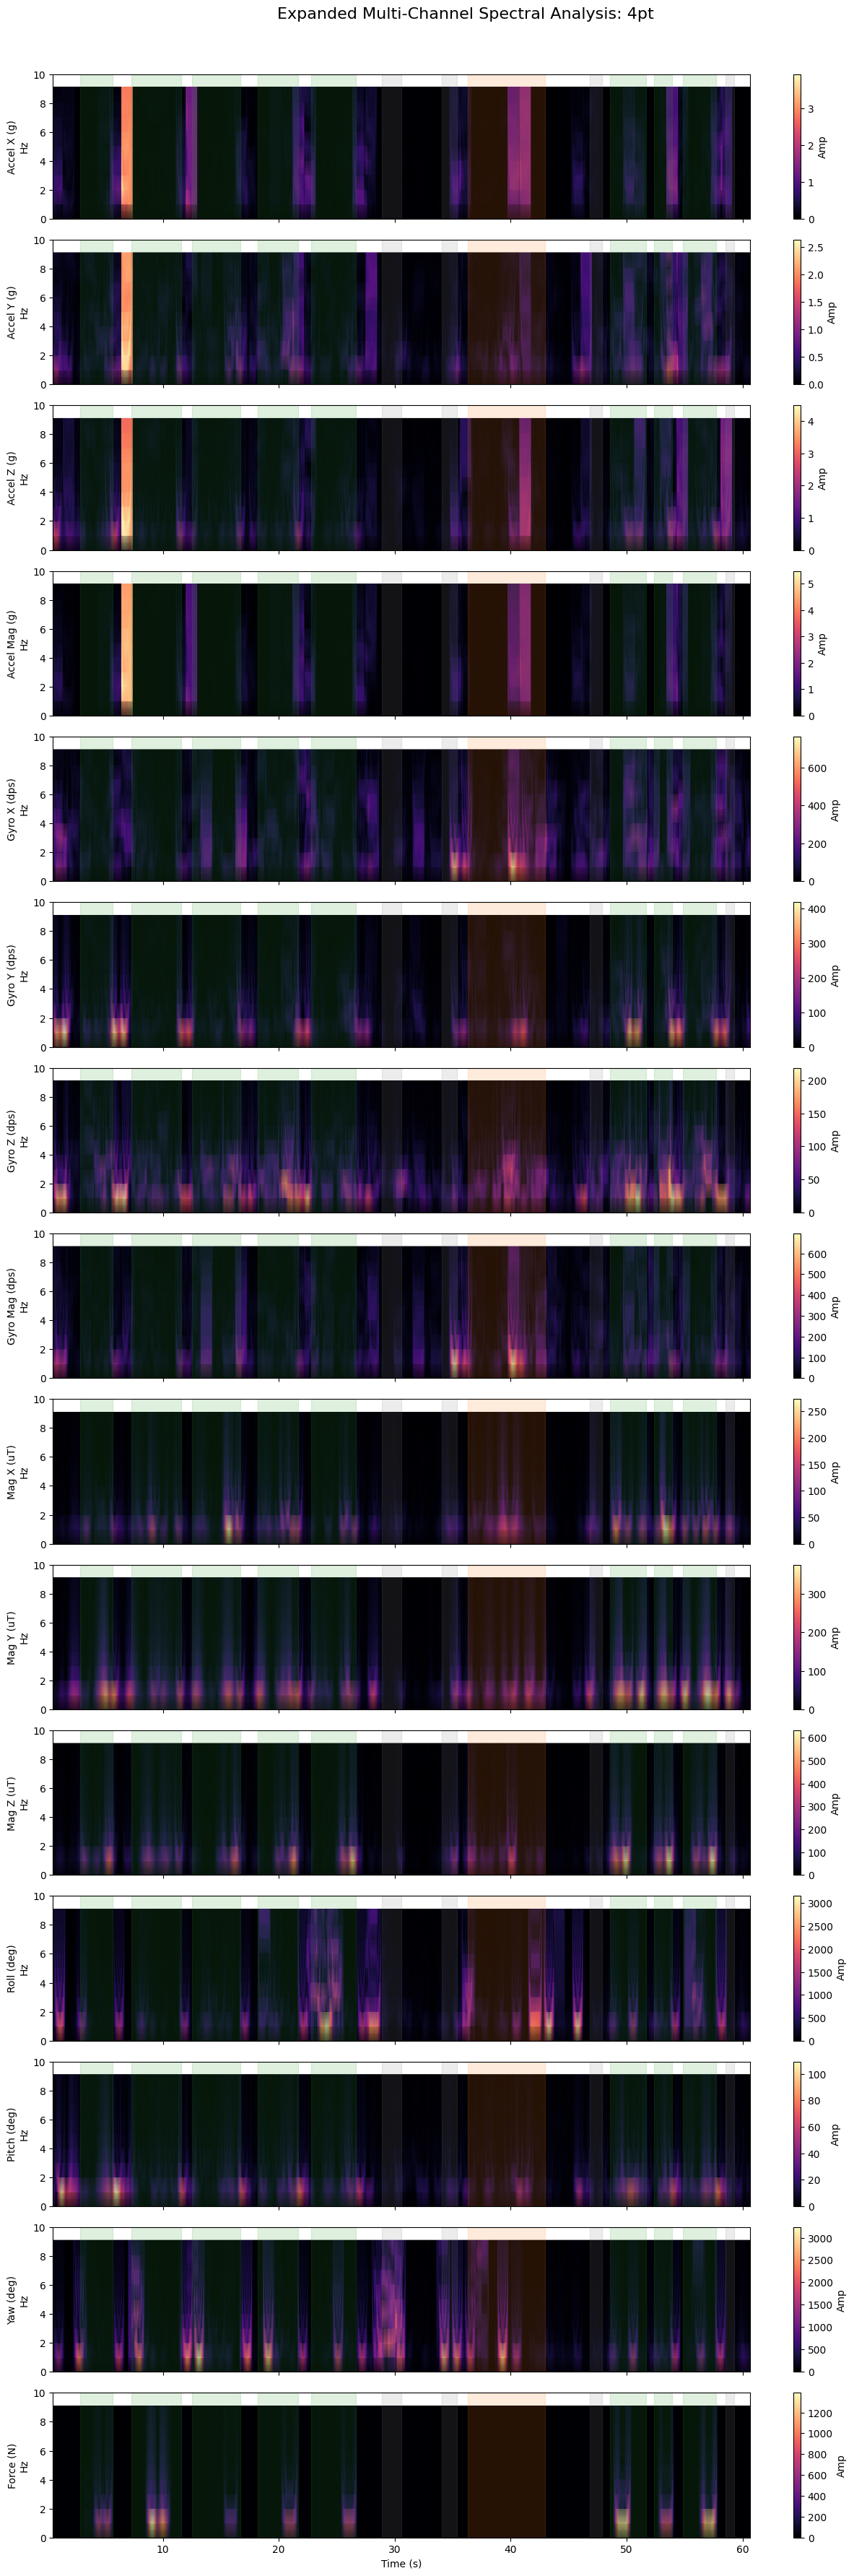

In [ ]:
# Run the updated expanded analysis
plot_multi_channel_fft("4pt", window_s=1.0, step_s=0.05, max_freq=10.0)

,dataset,file,candidates,accepted,steps,max_z,max_force_n
0,swing,hassan_swing.csv,13,13,12,16.6,647.8
1,2pt,hassan_2pt_left_crutch_right_damaged.csv,12,10,7,42.7,473.7
2,3pt,hassan3pt_left_crutch_left_damaged.csv,17,16,15,12.0,164.5
3,4pt,hassandata1_4pt_left_crutch_right_damaged.csv,15,9,3,72.7,171.4


,dataset,start_s,release_s,duration_s,kind,accepted,reject_reason,peak_amp,area
0,swing,1.749,2.970,1.221,step,True,,79.778069,51.770872
1,swing,3.861,4.686,0.825,step,True,,72.066032,34.583597
2,swing,6.171,6.798,0.627,step,True,,68.368645,28.752169
3,swing,8.118,8.943,0.825,step,True,,82.442886,37.588564
4,swing,10.560,11.187,0.627,step,True,,69.212663,26.513910
5,swing,12.441,13.299,0.858,step,True,,75.041179,39.064219
6,swing,14.520,16.962,2.442,sustained,True,,107.532100,155.349960
7,swing,17.721,18.579,0.858,step,True,,62.041670,31.467696
8,swing,19.470,20.031,0.561,step,True,,69.293827,25.230574
9,swing,21.681,22.209,0.528,step,True,,56.021160,19.711157


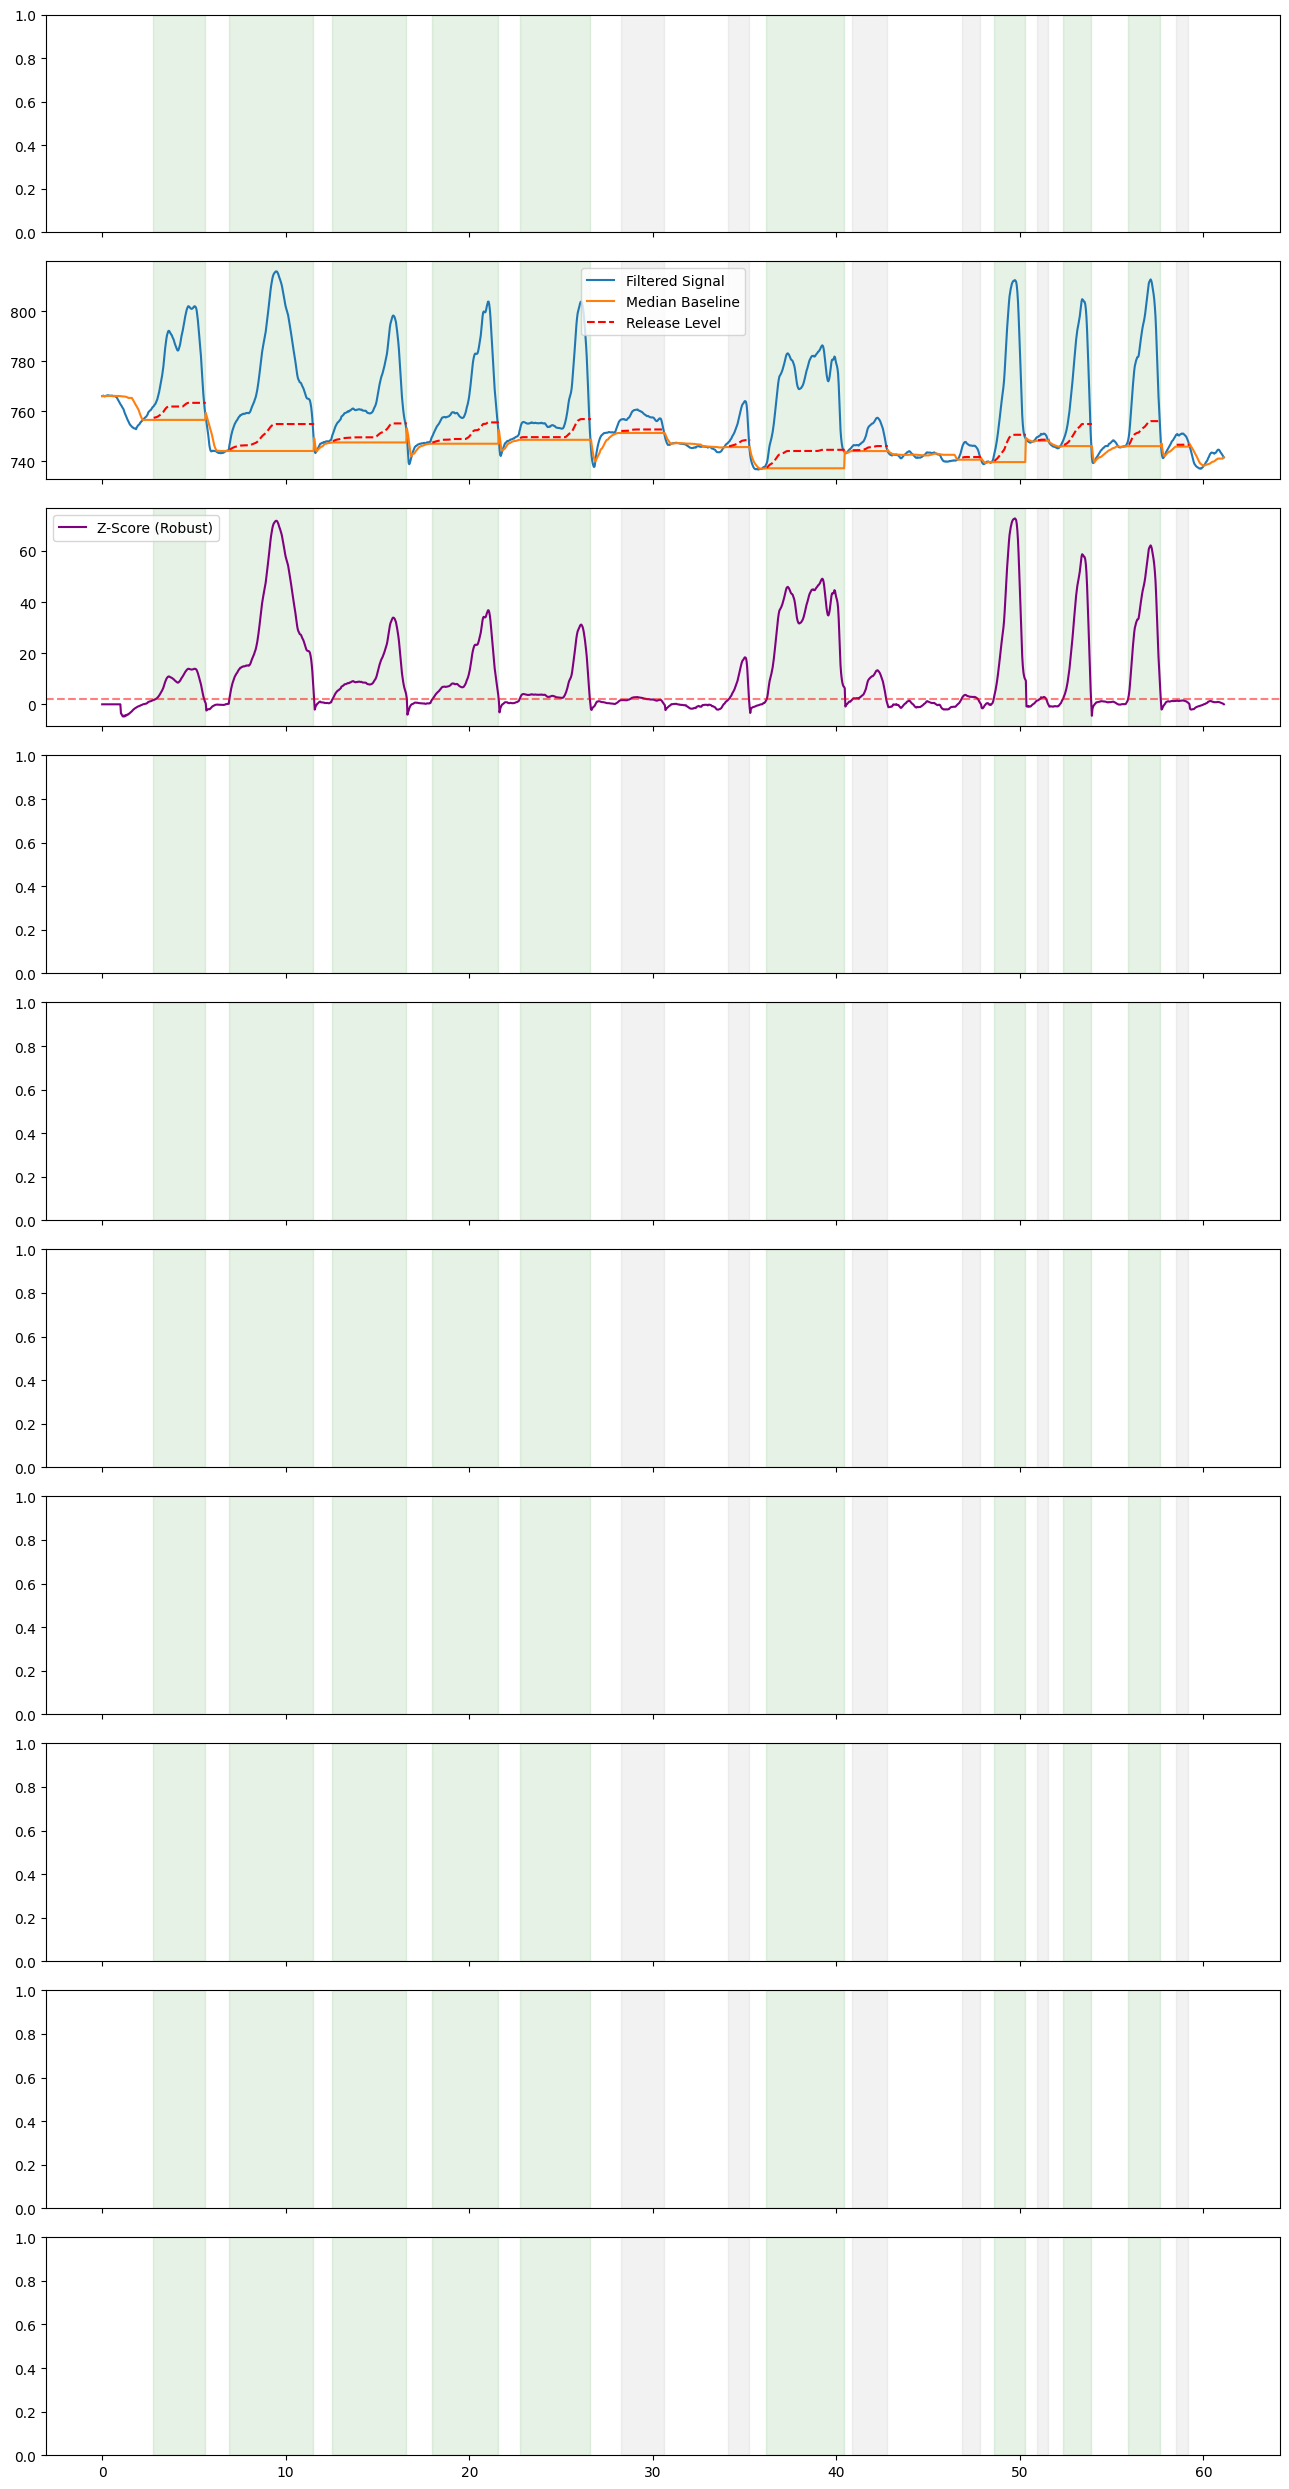

In [ ]:
# Fix: Re-defining the plot call to handle the column name change from 'baseline_mean' to 'baseline_median'
def plot_peak_release_dataset_fixed(dataset_name):
    detected_df, events_df, csv_path, startup_b0 = analyze_dataset(dataset_name)
    if detected_df is None: return

    fig, axs = plt.subplots(10, 1, figsize=(13, 25), sharex=True)

    # Plot 1: Signal and Baseline
    axs[1].plot(detected_df["time_s"], detected_df["detector_signal_lpf_uT"], label="Filtered Signal")
    # Using 'baseline_median' as defined in the updated pipeline
    if "baseline_median" in detected_df.columns:
        axs[1].plot(detected_df["time_s"], detected_df["baseline_median"], lw=1.5, label="Median Baseline")

    axs[1].plot(detected_df["time_s"], detected_df["release_level"], ls="--", color="red", label="Release Level")
    axs[1].legend()

    # Plot 2: Z-Score
    axs[2].plot(detected_df["time_s"], detected_df["z_score"], color="purple", label="Z-Score (Robust)")
    axs[2].axhline(Z_ENTER, color="red", ls="--", alpha=0.5)
    axs[2].legend()

    # ... (Overlaying events)
    for event in events_df.to_dict("records"):
        color = "green" if event["accepted"] else "gray"
        for ax in axs: ax.axvspan(event["start_s"], event["release_s"], color=color, alpha=0.1)

    plt.tight_layout(); plt.show()

# Run the fixed comparison and plot
compare_peak_release_datasets()
plot_peak_release_dataset_fixed("4pt")

### Explanation of Key Terms

*   **Filtered Signal (LPF):** This is the raw magnetic data after applying a Low-Pass Filter. It removes high-frequency 'jitter' so the algorithm can focus on the steady increase in magnetism that occurs when the crutch is loaded.
*   **Median Baseline:** This represents the 'quiet' state of the sensor. The algorithm constantly calculates the median value of the signal when it thinks you are in swing phase.
*   **Z-Score:** This is the statistical 'surprise' factor. It measures how many standard deviations the current signal is away from the baseline. When $Z > 2.0$, the algorithm triggers a 'Loaded' state.
*   **Release Level:** Once a peak is detected, the algorithm calculates a threshold (usually 30% of the peak). When the signal drops below this level, it confirms the crutch has left the ground.

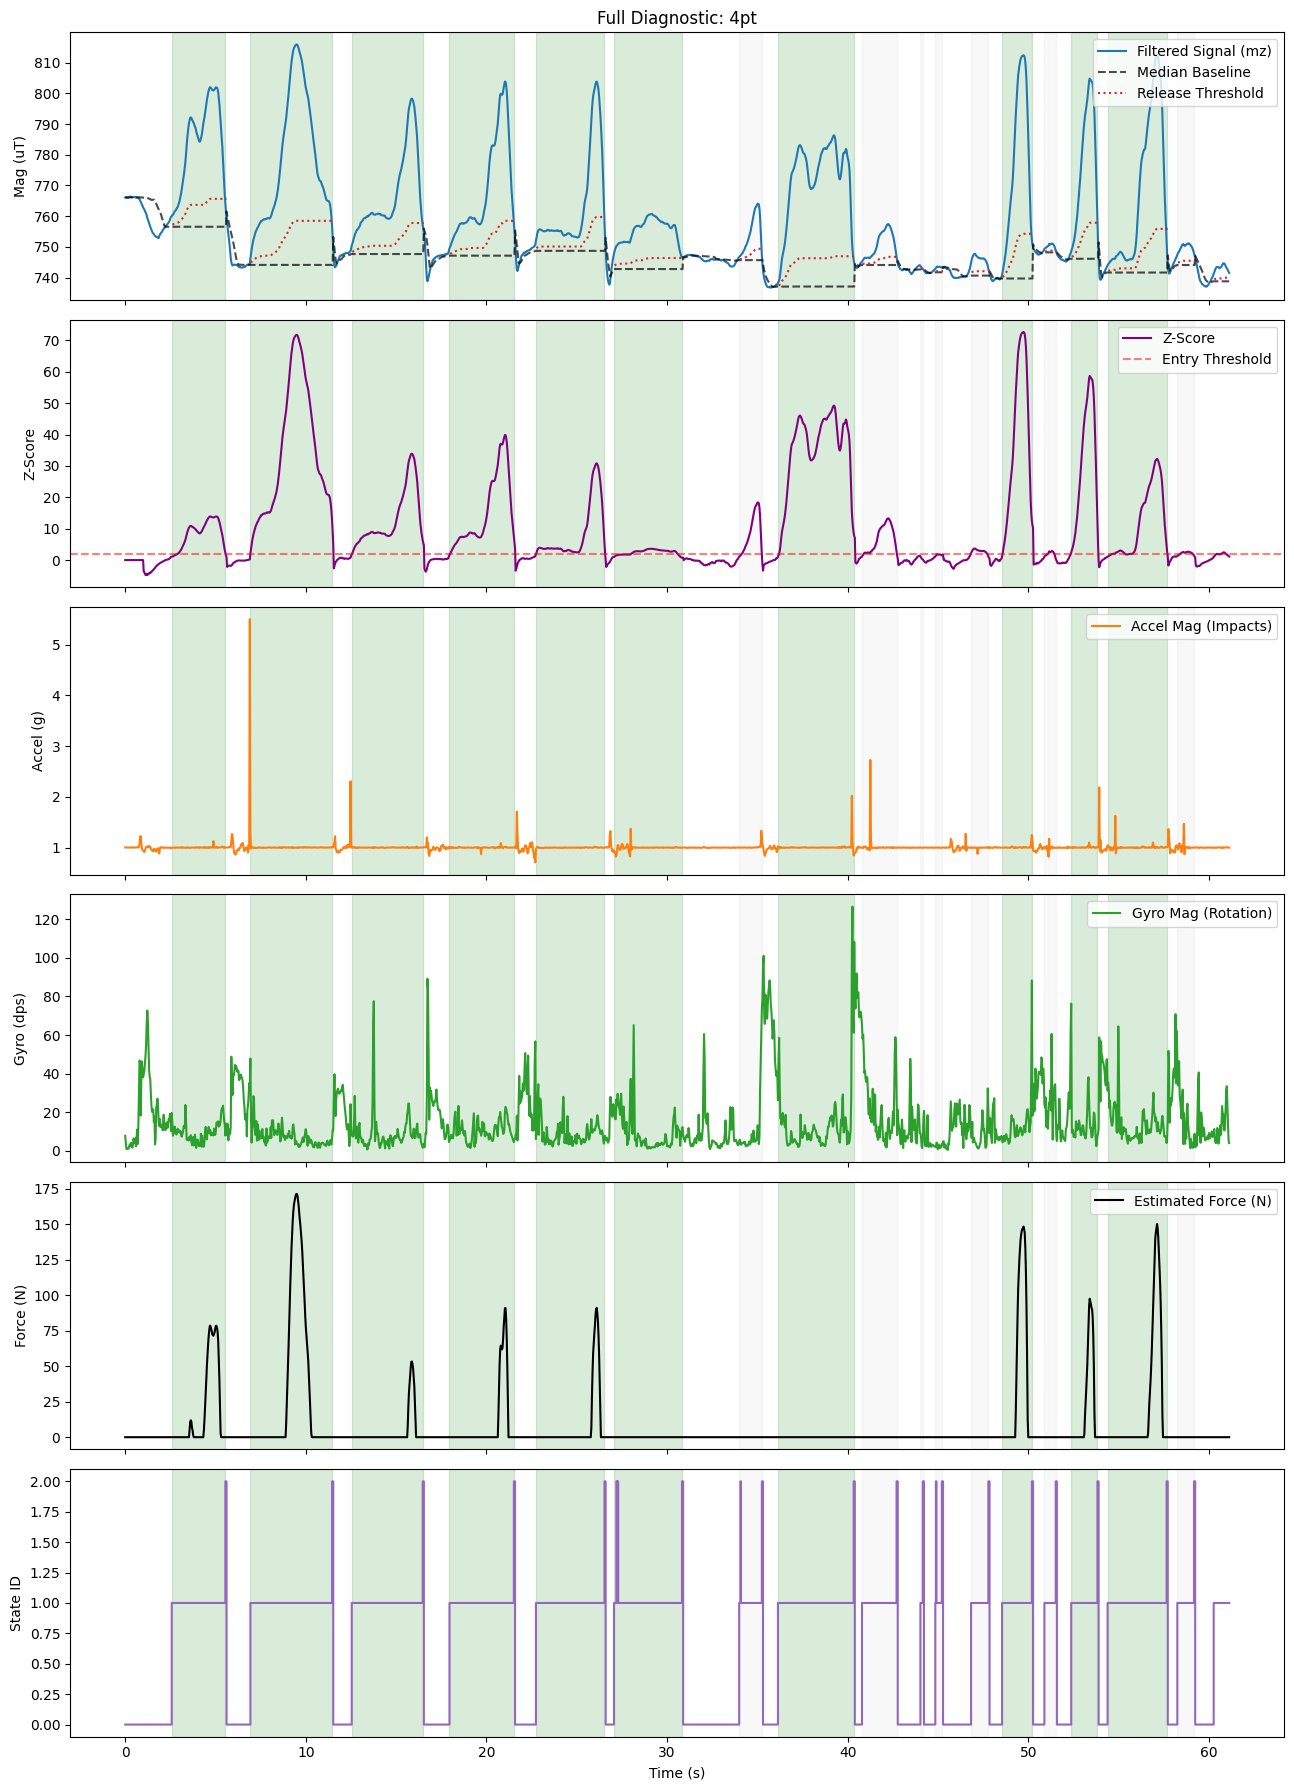

In [ ]:
def plot_full_diagnostic(dataset_name):
    # Re-run analysis to get the full DataFrames
    detected_df, events_df, csv_path, startup_b0 = analyze_dataset(dataset_name)
    if detected_df is None: return

    # We will plot 6 key diagnostic rows
    fig, axs = plt.subplots(6, 1, figsize=(13, 18), sharex=True)

    # 1. Magnetometer & Baseline
    axs[0].plot(detected_df['time_s'], detected_df['detector_signal_lpf_uT'], label='Filtered Signal (mz)', color='C0')
    if 'baseline_median' in detected_df.columns:
        axs[0].plot(detected_df['time_s'], detected_df['baseline_median'], label='Median Baseline', ls='--', color='black', alpha=0.7)
    axs[0].plot(detected_df['time_s'], detected_df['release_level'], label='Release Threshold', color='C3', ls=':')
    axs[0].set_ylabel('Mag (uT)')
    axs[0].legend(loc='upper right')
    axs[0].set_title(f'Full Diagnostic: {dataset_name}')

    # 2. Z-Score
    axs[1].plot(detected_df['time_s'], detected_df['z_score'], color='purple', label='Z-Score')
    axs[1].axhline(2.0, color='red', ls='--', alpha=0.5, label='Entry Threshold')
    axs[1].set_ylabel('Z-Score')
    axs[1].legend(loc='upper right')

    # 3. Accelerometer Magnitude
    axs[2].plot(detected_df['time_s'], detected_df['accel_mag_g'], color='C1', label='Accel Mag (Impacts)')
    axs[2].set_ylabel('Accel (g)')
    axs[2].legend(loc='upper right')

    # 4. Gyroscope Magnitude
    axs[3].plot(detected_df['time_s'], detected_df['gyro_mag_dps'], color='C2', label='Gyro Mag (Rotation)')
    axs[3].set_ylabel('Gyro (dps)')
    axs[3].legend(loc='upper right')

    # 5. Estimated Force
    axs[4].plot(detected_df['time_s'], detected_df['force_n'], color='black', label='Estimated Force (N)')
    axs[4].set_ylabel('Force (N)')
    axs[4].legend(loc='upper right')

    # 6. Detector State
    # Mapping states to numbers for visualization
    state_map = {'idle': 0, 'zeroing': 0, 'loaded': 1, 'releasing': 2}
    state_ints = detected_df['state'].map(state_map)
    axs[5].step(detected_df['time_s'], state_ints, where='post', color='C4', label='State (0:Idle, 1:Load, 2:Rel)')
    axs[5].set_ylabel('State ID')
    axs[5].set_xlabel('Time (s)')

    # Overlay Stance Spans on all axes
    for _, ev in events_df.iterrows():
        color = 'green' if ev['accepted'] else 'gray'
        alpha = 0.15 if ev['accepted'] else 0.05
        for ax in axs:
            ax.axvspan(ev['start_s'], ev['release_s'], color=color, alpha=alpha)

    plt.tight_layout()
    plt.show()

# Run it for the 4pt dataset
plot_full_diagnostic('4pt')

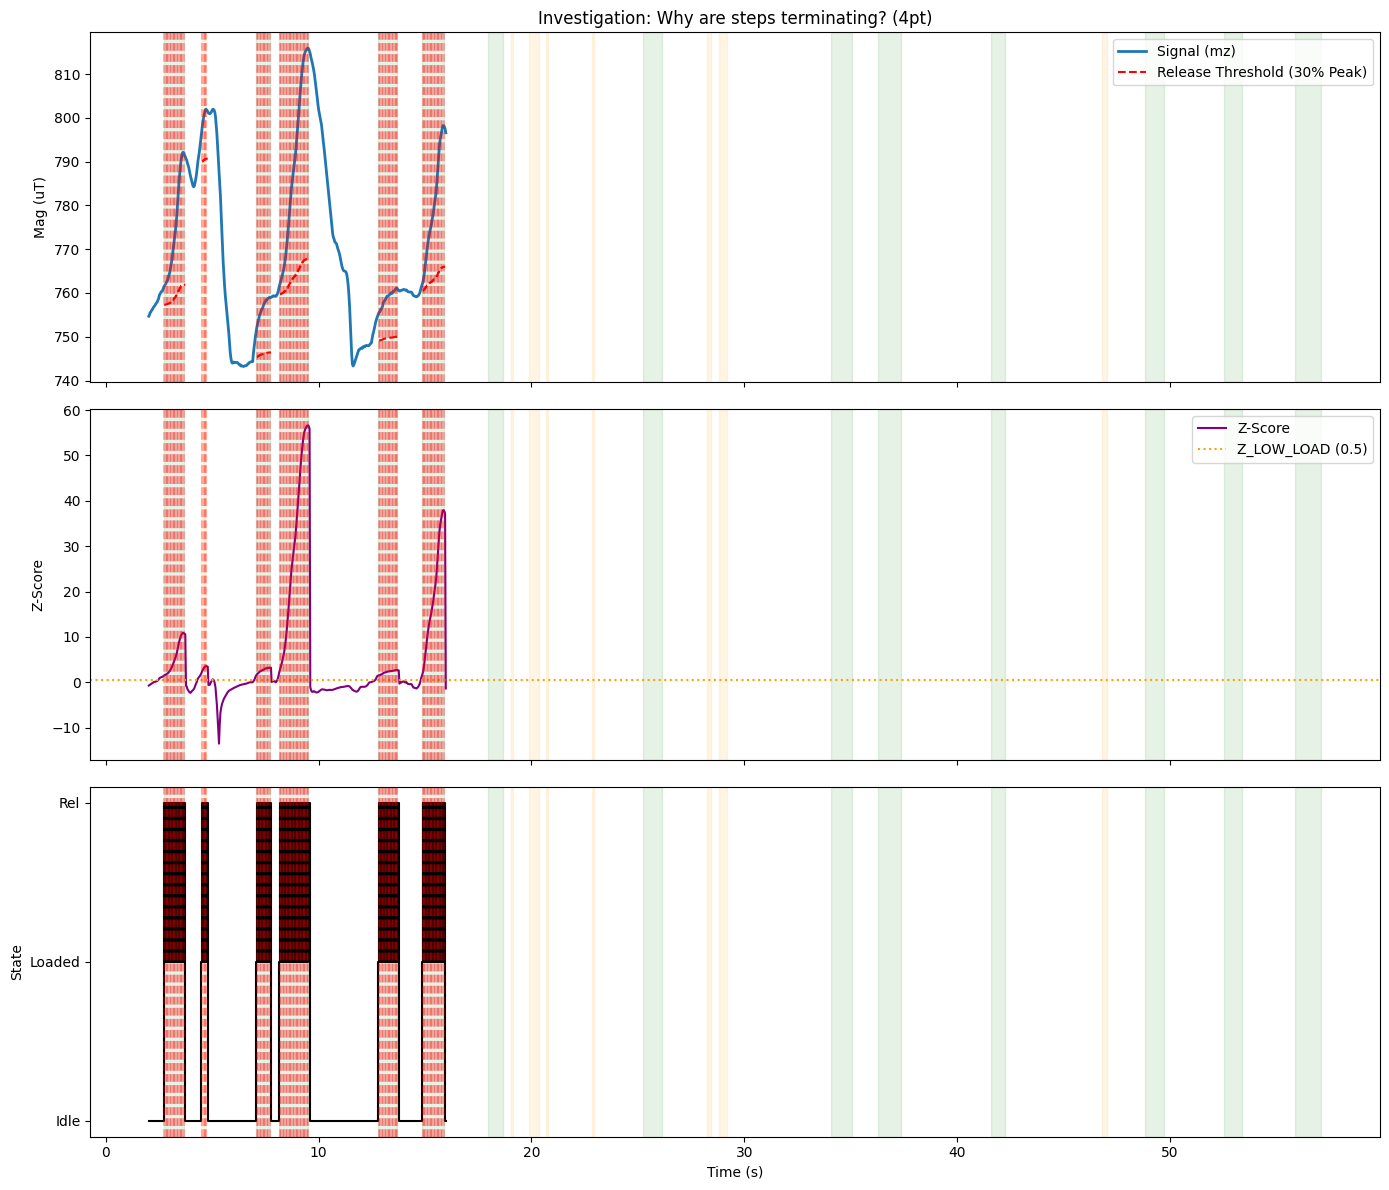

In [ ]:
def investigate_missed_steps(dataset_name='4pt'):
    # FIXED: Added _path and _b0 to handle the 4 values returned by analyze_dataset
    out, events, _path, _b0 = analyze_dataset(dataset_name)
    if out is None: return

    # Focus on the first ~15 seconds to see the initial peaks clearly
    zoom_mask = (out['time_s'] >= 2.0) & (out['time_s'] <= 16.0)
    df_zoom = out[zoom_mask].copy()

    fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # Plot 1: Magnetometer Signal & Release Thresholds
    axs[0].plot(df_zoom['time_s'], df_zoom['detector_signal_lpf_uT'], label='Signal (mz)', color='C0', lw=2)
    axs[0].plot(df_zoom['time_s'], df_zoom['release_level'], label='Release Threshold (30% Peak)', color='red', ls='--')
    axs[0].set_ylabel('Mag (uT)')
    axs[0].set_title(f'Investigation: Why are steps terminating? ({dataset_name})')
    axs[0].legend()

    # Plot 2: Z-Score vs Z_LOW_LOAD
    axs[1].plot(df_zoom['time_s'], df_zoom['z_score'], label='Z-Score', color='purple')
    # Use the value from the pipeline cell
    z_low = 0.5
    axs[1].axhline(z_low, color='orange', ls=':', label=f'Z_LOW_LOAD ({z_low})')
    axs[1].set_ylabel('Z-Score')
    axs[1].legend()

    # Plot 3: State Transitions
    state_map = {'idle': 0, 'zeroing': 0, 'loaded': 1, 'releasing': 2}
    axs[2].step(df_zoom['time_s'], df_zoom['state'].map(state_map), where='post', color='black', label='State')
    axs[2].set_yticks([0, 1, 2])
    axs[2].set_yticklabels(['Idle', 'Loaded', 'Rel'])
    axs[2].set_ylabel('State')

    # FIXED: Combined filtering with '&' to resolve the UserWarning
    is_releasing = (df_zoom['state'] == 'releasing')
    was_loaded = (df_zoom['state'].shift(1) == 'loaded')
    rel_points = df_zoom[is_releasing & was_loaded]

    for t_rel in rel_points['time_s']:
        for ax in axs: ax.axvline(t_rel, color='red', alpha=0.3, ls='--')

    # Overlay accepted/rejected events
    for _, ev in events.iterrows():
        color = 'green' if ev['accepted'] else 'orange'
        alpha = 0.1
        for ax in axs: ax.axvspan(ev['start_s'], ev['release_s'], color=color, alpha=alpha)

    plt.xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

investigate_missed_steps('4pt')

In [ ]:
def corroborated_pipeline(df, z_soft=1.0, z_hard=2.0, corr_window_ms=80.0):
    """
    Enhanced pipeline using Soft Entry logic.
    A step starts if Z >= z_soft AND secondary sensors (Accel/Gyro) corroborate.
    Falls back to z_hard if no corroboration is found but signal is very strong.
    """
    # Re-using the logic from run_peak_release_pipeline but adding corroboration triggers
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    startup_std_floor = max(startup["detector_signal_lpf_uT"].std(ddof=1), STD_FLOOR)
    baseline_window = deque(startup["detector_signal_lpf_uT"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        return vals.mean(), max(vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    release_candidate_t = None
    last_release_t = -1e9
    post_release_baseline_samples = 0
    baseline_at_entry = None
    peak_signal = None
    release_level = np.nan
    events = []

    # Arrays for column output
    states, baseline_means, z_scores, release_levels, peak_values = [], [], [], [], []
    corroborated_flags = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.detector_signal_lpf_uT

        # Secondary triggers for corroboration
        # Look for a sharp dip in AZ (impact) or high gyro activity
        accel_dip = row.az_g < -0.1
        gyro_active = (abs(row.gz_dps) > 20) or (abs(row.gy_dps) > 20)
        is_corroborated = accel_dip or gyro_active

        if t <= STARTUP_ZERO_S:
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing"); baseline_means.append(baseline_mean); z_scores.append(0.0)
            release_levels.append(np.nan); peak_values.append(np.nan); corroborated_flags.append(False)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            # Soft Entry Logic: Trigger on soft Z but require corroboration,
            # OR trigger immediately on Hard Z.
            if can_start and (z >= z_hard or (z >= z_soft and is_corroborated)):
                state = "loaded"
                load_start_t = t
                baseline_at_entry = baseline_mean
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
                post_release_baseline_samples = 0
            elif post_release_baseline_samples > 0:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
                post_release_baseline_samples -= 1
            release_levels.append(np.nan); peak_values.append(np.nan)

        elif state == "loaded":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
            if b <= release_level:
                state = "releasing"
                release_candidate_t = t
            release_levels.append(release_level); peak_values.append(peak_signal)

        elif state == "releasing":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
            if b > release_level:
                state = "loaded"
                release_candidate_t = None
            elif (t - release_candidate_t) * 1000.0 >= RELEASE_CONFIRM_MS:
                release_t = release_candidate_t
                events.append({
                    "start_s": load_start_t, "release_s": release_t, "confirm_s": t,
                    "duration_s": release_t - load_start_t,
                    "kind": "step" if (release_t - load_start_t) < SUSTAINED_CUTOFF_S else "sustained",
                    "peak_amp": peak_signal - baseline_at_entry,
                    "area": event_area(df, load_start_t, release_t, baseline_at_entry)
                })
                # Reset baseline at release point
                release_samples = df.loc[(df["time_s"] >= release_t) & (df["time_s"] <= t), "detector_signal_lpf_uT"]
                baseline_window.clear()
                for s in release_samples: baseline_window.append(s)
                baseline_mean, baseline_std = window_stats(baseline_window)
                post_release_baseline_samples = max(POST_RELEASE_BASELINE_SAMPLES - len(release_samples), 0)
                state = "idle"; last_release_t = t
            release_levels.append(release_level); peak_values.append(peak_signal)

        states.append(state); baseline_means.append(baseline_mean); z_scores.append(z); corroborated_flags.append(is_corroborated)

    out = df.copy()
    out["state"] = states
    out["z_score"] = z_scores
    out["is_corroborated"] = corroborated_flags
    return out, classify_rejections(pd.DataFrame(events))

--- Analysis for Sina: 2-Point Gait (2pointgatesina5.csv) ---
Total Candidates: 22
Accepted Steps/Sustained: 15


,start_s,release_s,duration_s,kind,peak_amp
2,6.236,7.589,1.353,step,33.357091
4,11.087,14.354,3.267,step,111.783463
5,15.245,18.182,2.937,step,78.460722
6,19.964,21.086,1.122,step,37.209951
7,22.802,24.320,1.518,step,73.787866
9,43.889,44.747,0.858,step,72.289833
10,45.341,47.915,2.574,step,130.876519
11,48.212,49.334,1.122,step,69.973124
12,50.192,51.380,1.188,step,69.168937
14,54.416,55.043,0.627,step,68.054109


,peak-release summary
dataset,sina_2pt_temp
file,2pointgatesina5.csv
rows,1961
duration_s,64.679
mag_axis_for_detector,mz_uT
use_abs_field,False
startup_b0_uT,671.690726
candidates,16
accepted,13
rejected,3


,dataset,start_s,release_s,duration_s,kind,accepted,reject_reason,peak_amp,area
0,sina_2pt_temp,2.507,2.639,0.132,step,False,"short,small_peak,small_area",10.709502,1.138064
1,sina_2pt_temp,6.533,7.523,0.990,step,True,,29.488323,20.722297
2,sina_2pt_temp,11.219,13.232,2.013,step,True,,92.572397,129.394042
3,sina_2pt_temp,15.410,16.664,1.254,step,True,,60.185229,49.999721
4,sina_2pt_temp,23.033,24.221,1.188,step,True,,47.881130,33.671100
5,sina_2pt_temp,43.955,44.615,0.660,step,True,,45.737373,23.685492
6,sina_2pt_temp,45.473,47.882,2.409,step,True,,126.505810,188.080093
7,sina_2pt_temp,48.212,49.334,1.122,step,True,,69.302477,52.427627
8,sina_2pt_temp,50.192,51.380,1.188,step,True,,69.168937,55.517142
9,sina_2pt_temp,52.832,53.228,0.396,step,False,short,40.252699,12.427114


/tmp/ipykernel_3682/2497019004.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[3].legend(loc="upper right")


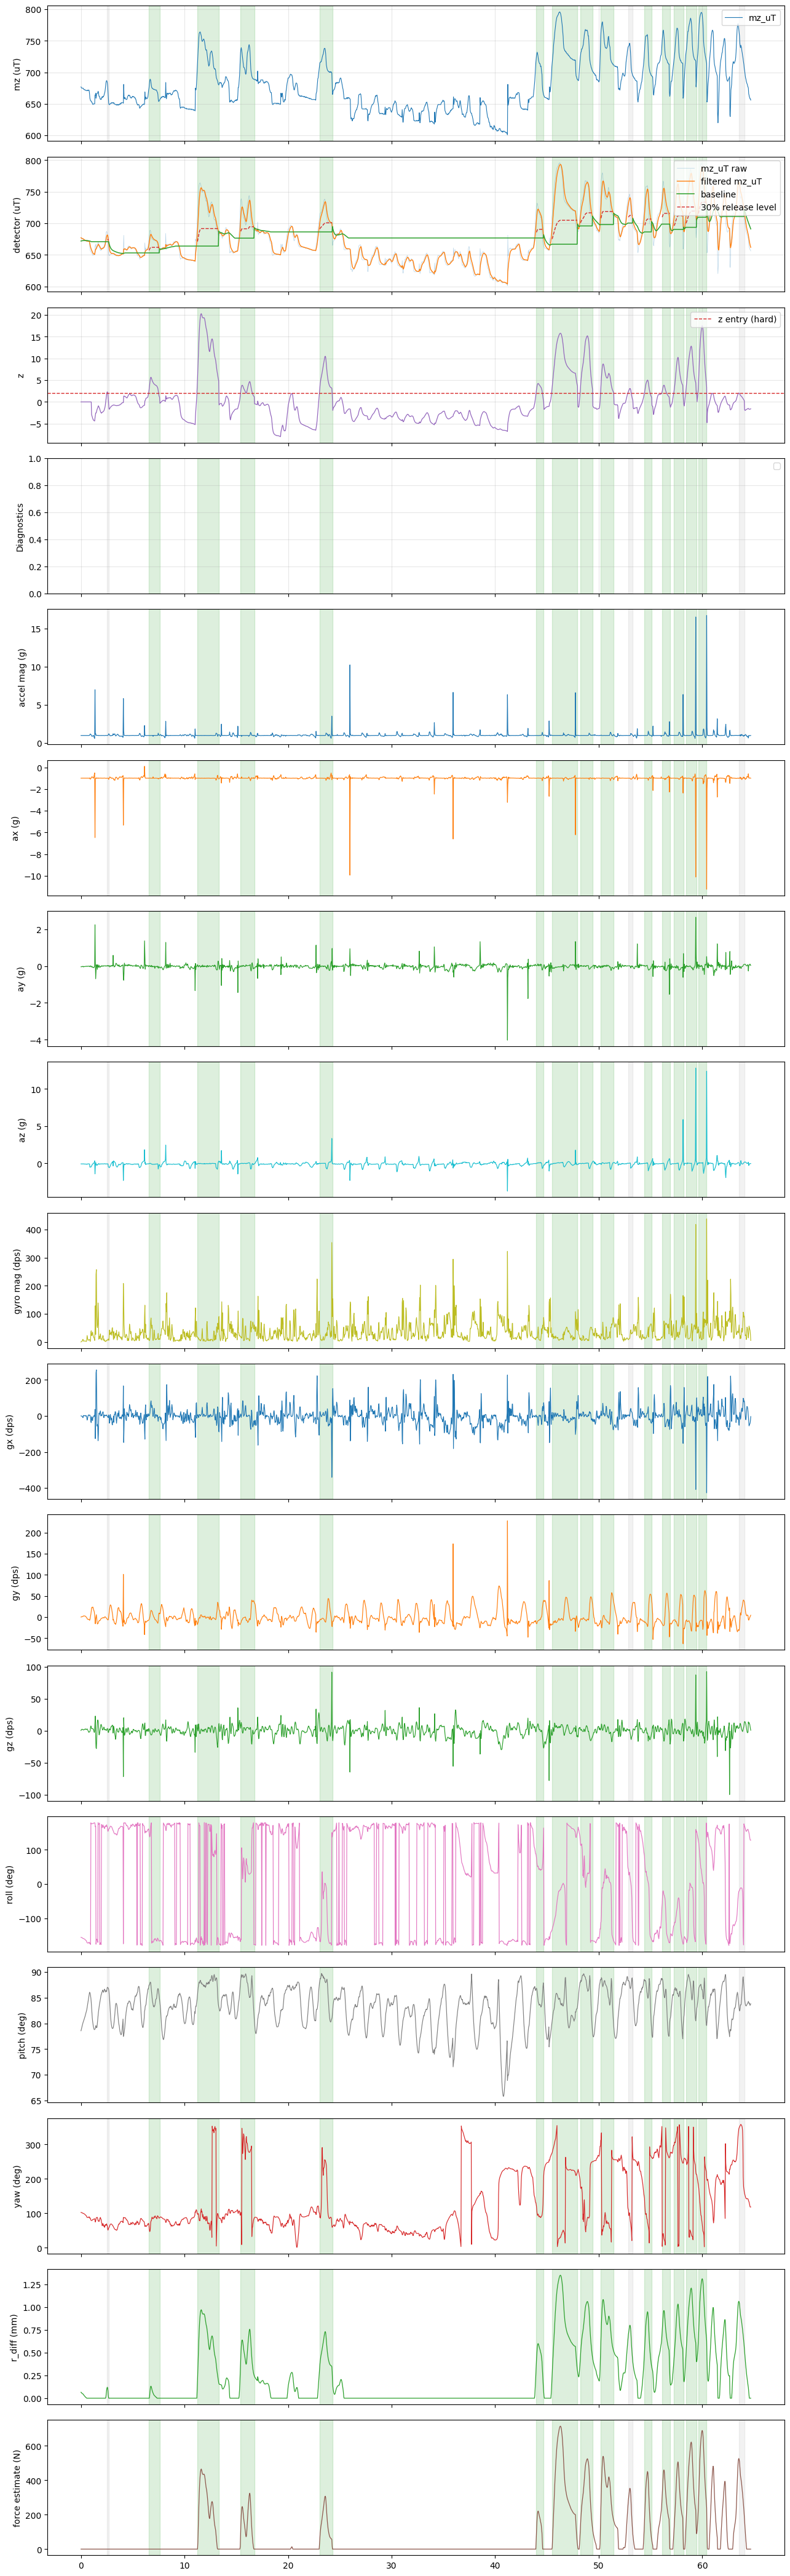

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Setup paths and parameters for Sina 2pt data
sina_2pt_file = "2pointgatesina5.csv"

# Ensure the file exists
if Path(sina_2pt_file).exists():
    # 2. Load the raw data
    df_raw, _ = load_hassan_capture_csv(sina_2pt_file)

    # 3. Add Force and displacement columns
    df_force, _ = add_force_columns(df_raw)

    # 4. Run the Corroborated Pipeline (Soft Z=1.0, Hard Z=2.0)
    # This is the 'Enhanced' model we discussed previously
    df_detected, events_df = corroborated_pipeline(df_force, z_soft=1.0, z_hard=2.0)

    # 5. Display detection summary
    print(f"--- Analysis for Sina: 2-Point Gait ({sina_2pt_file}) ---")
    print(f"Total Candidates: {len(events_df)}")
    print(f"Accepted Steps/Sustained: {len(events_df[events_df['accepted']])}")
    display(events_df[events_df['accepted']][['start_s', 'release_s', 'duration_s', 'kind', 'peak_amp']])

    # 6. Visualization using the custom plotting function
    # We'll temporarily map it to DATASET_PATHS so the plotter can find it
    DATASET_PATHS['sina_2pt_temp'] = Path(sina_2pt_file)

    # Note: plot_peak_release_dataset expects specific columns, so we ensure compatibility
    # We'll re-run analyze_dataset logic locally for the plot if needed,
    # but here we can call the plotter after manually preparing detected_df.
    plot_peak_release_dataset('sina_2pt_temp')
else:
    print(f"Error: {sina_2pt_file} not found in current directory.")

--- Analysis for Hassan: 2-Point Gait (hassan_2pt_left_crutch_right_damaged.csv) ---
Total Candidates: 11
Accepted Steps/Sustained: 10


,start_s,release_s,duration_s,kind,peak_amp
0,1.782,2.838,1.056,step,92.696968
1,4.290,5.115,0.825,step,79.292847
2,6.732,7.524,0.792,step,67.338593
3,8.844,9.603,0.759,step,46.049960
5,12.342,13.530,1.188,step,61.581895
6,22.605,23.793,1.188,step,72.855488
7,25.608,27.027,1.419,step,70.286376
8,28.644,29.469,0.825,step,85.922506
9,31.185,32.142,0.957,step,66.883877
10,33.693,34.518,0.825,step,71.633489


,peak-release summary
dataset,hassan_2pt_temp
file,hassan_2pt_left_crutch_right_damaged.csv
rows,1101
duration_s,36.3
mag_axis_for_detector,mz_uT
use_abs_field,False
startup_b0_uT,727.563282
candidates,11
accepted,10
rejected,1


,dataset,start_s,release_s,duration_s,kind,accepted,reject_reason,peak_amp,area
0,hassan_2pt_temp,1.782,2.838,1.056,step,True,,92.696968,55.708439
1,hassan_2pt_temp,4.290,5.115,0.825,step,True,,79.292847,41.100090
2,hassan_2pt_temp,6.732,7.524,0.792,step,True,,67.338593,31.355078
3,hassan_2pt_temp,8.877,9.603,0.726,step,True,,45.901449,23.568106
4,hassan_2pt_temp,11.352,11.979,0.627,step,False,"small_peak,small_area",18.874985,8.327809
5,hassan_2pt_temp,12.342,13.530,1.188,step,True,,61.581895,53.179342
6,hassan_2pt_temp,22.605,23.793,1.188,step,True,,72.855488,54.720313
7,hassan_2pt_temp,25.773,27.027,1.254,step,True,,70.286376,52.677713
8,hassan_2pt_temp,28.644,29.469,0.825,step,True,,85.922506,50.433854
9,hassan_2pt_temp,31.185,32.142,0.957,step,True,,66.883877,44.691070


/tmp/ipykernel_3682/2497019004.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[3].legend(loc="upper right")


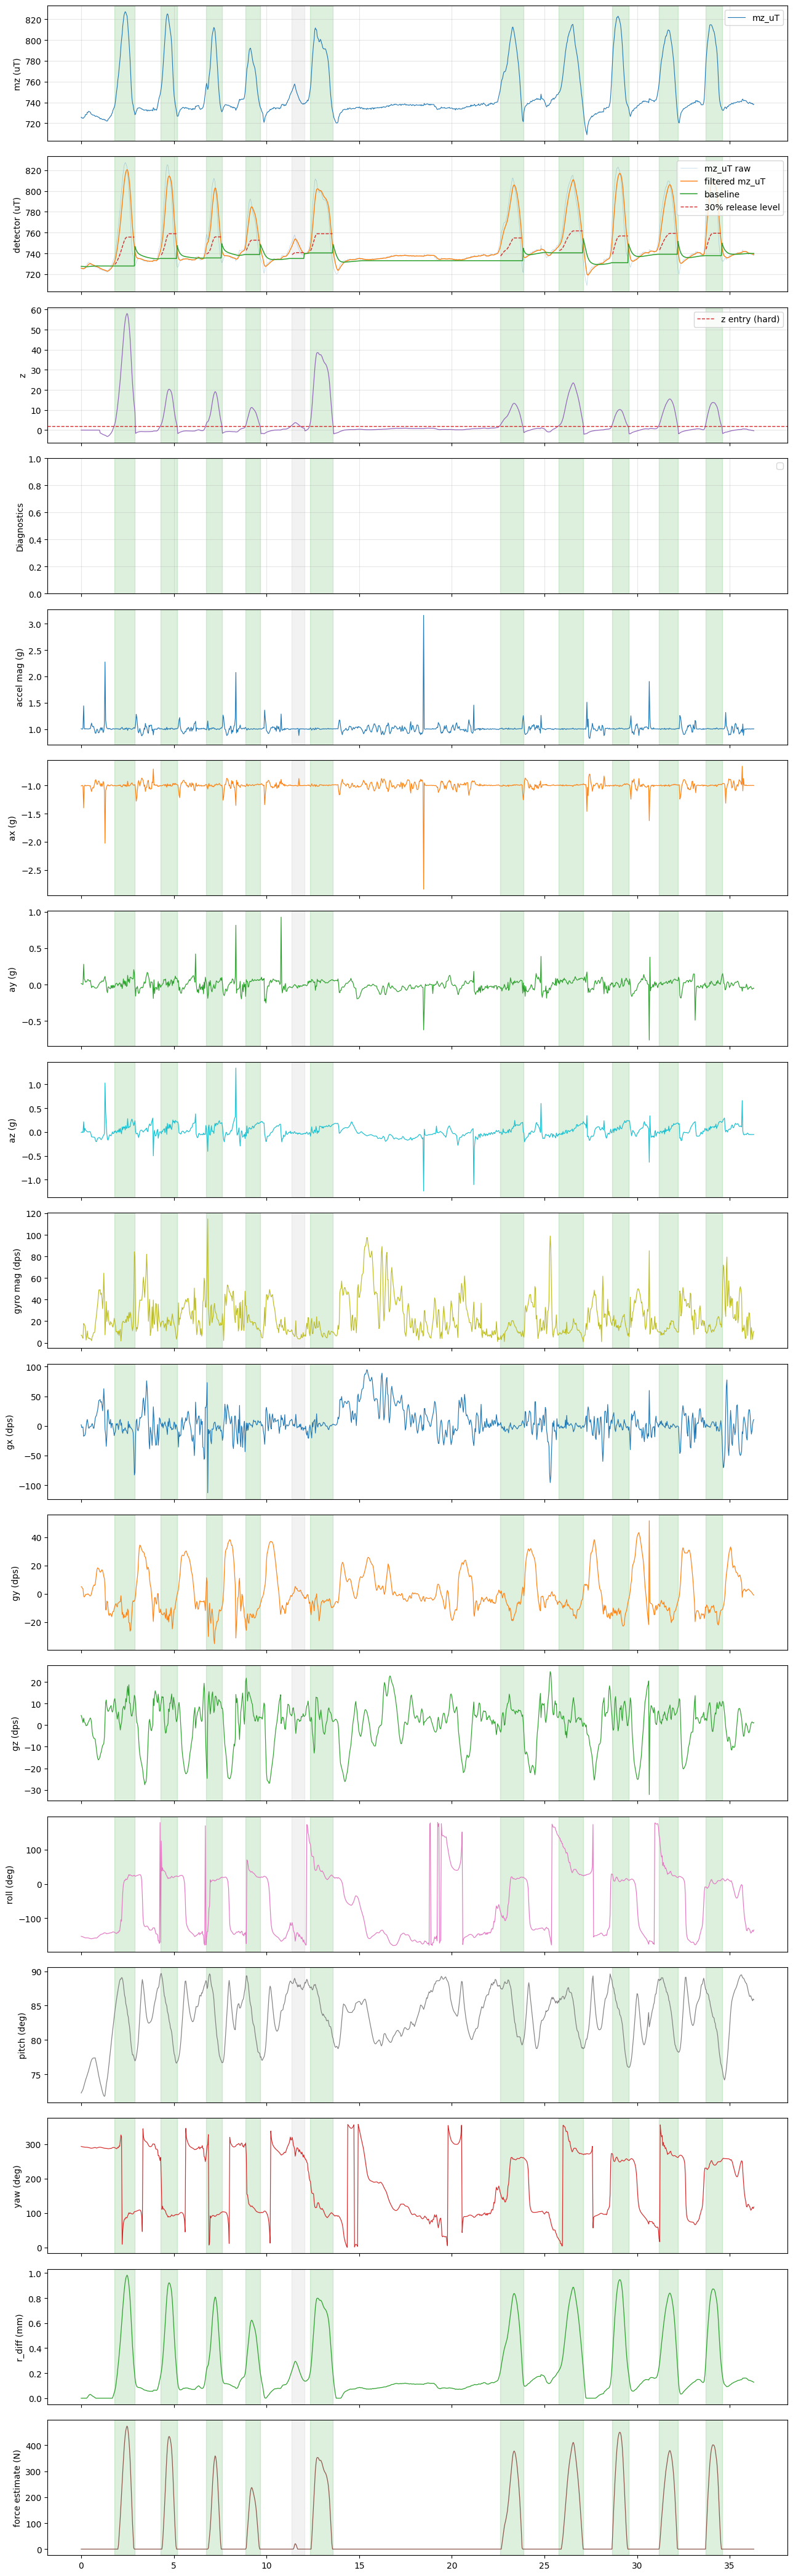

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Setup paths for Hassan 2pt data
hassan_2pt_file = "hassan_2pt_left_crutch_right_damaged.csv"

# Ensure the file exists
if Path(hassan_2pt_file).exists():
    # 2. Load the raw data
    df_raw, _ = load_hassan_capture_csv(hassan_2pt_file)

    # 3. Add Force and displacement columns
    df_force, _ = add_force_columns(df_raw)

    # 4. Run the Corroborated Pipeline (Soft Z=1.0, Hard Z=2.0)
    df_detected, events_df = corroborated_pipeline(df_force, z_soft=1.0, z_hard=2.0)

    # 5. Display detection summary
    print(f"--- Analysis for Hassan: 2-Point Gait ({hassan_2pt_file}) ---")
    print(f"Total Candidates: {len(events_df)}")
    print(f"Accepted Steps/Sustained: {len(events_df[events_df['accepted']])}")
    display(events_df[events_df['accepted']][['start_s', 'release_s', 'duration_s', 'kind', 'peak_amp']])

    # 6. Visualization
    # Temporarily map it to DATASET_PATHS for the standard plotter to work
    DATASET_PATHS['hassan_2pt_temp'] = Path(hassan_2pt_file)
    plot_peak_release_dataset('hassan_2pt_temp')
else:
    print(f"Error: {hassan_2pt_file} not found.")

# Exporting to Better Format

In [ ]:
merged_dfs = []

for gait_name in DATASET_PATHS.keys():
    # 1. Run the existing analysis pipeline for each file
    detected_df, events_df, _, _ = analyze_dataset(gait_name)

    if detected_df is None or detected_df.empty:
        continue

    # 2. Add labeling
    temp_df = detected_df.copy()
    temp_df['gait_type'] = gait_name

    # 3. Create 'is_stance' column (the green/orange spans)
    # Default to False
    temp_df['is_stance'] = False

    if not events_df.empty:
        # Only consider accepted steps/sustained events
        accepted_events = events_df[events_df['accepted'] == True]

        for _, event in accepted_events.iterrows():
            # Mark rows within the start and release times as stance
            mask = (temp_df['time_s'] >= event['start_s']) & (temp_df['time_s'] <= event['release_s'])
            temp_df.loc[mask, 'is_stance'] = True

    merged_dfs.append(temp_df)

# Combine all into one master DataFrame
master_df = pd.concat(merged_dfs, ignore_index=True)

# Reorder columns to put labels at the front for readability
cols = ['gait_type', 'time_s', 'is_stance', 'force_n'] + [c for c in master_df.columns if c not in ['gait_type', 'time_s', 'is_stance', 'force_n']]
master_df = master_df[cols]

# Save to CSV
output_filename = "merged_gait_analysis.csv"
master_df.to_csv(output_filename, index=False)

print(f"Success! Merged {len(merged_dfs)} datasets.")
print(f"Total rows: {len(master_df)}")
print(f"File saved as: {output_filename}")

# Display a preview
display(master_df.head())
display(master_df['gait_type'].value_counts())

NameError: name 'run_peak_release_pipeline' is not defined

# Sina and Thomas Data Analysis

## Add the Force Measurements

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

subject_registry = {
    "hassan_swing.csv": ("Hassan", "swing"),
    "hassan_2pt_left_crutch_right_damaged.csv": ("Hassan", "2pt"),
    "hassan3pt_left_crutch_left_damaged.csv": ("Hassan", "3pt"),
    "hassandata1_4pt_left_crutch_right_damaged.csv": ("Hassan", "4pt"),
    "thomas_4pt.csv": ("Thomas", "4pt"),
    "2pointgatethomas.csv": ("Thomas", "2pt"),
    "3pointthomas4.csv": ("Thomas", "3pt"),
    "swingthroughthomas2.csv": ("Thomas", "swing"),
    "sina_4pt.csv": ("Sina", "4pt"),
    "2pointgatesina5.csv": ("Sina", "2pt"),
    "3pointsina3.csv": ("Sina", "3pt"),
    "swingthroughsina1.csv": ("Sina", "swing"),
    "tgfall.csv": ("Thomas", "fall"),
    "tgfall2.csv": ("Thomas", "fall"),
}

all_processed_data = []

for filename, (person, gait) in subject_registry.items():
    path_obj = Path(filename)
    if not path_obj.exists(): continue

    print(f"Processing {person} - {gait} ({filename}) using Corroborated Method...")

    # 1. Load data using the helper
    raw_df, _ = load_hassan_capture_csv(path_obj)
    if raw_df.empty: continue

    # 2. Handle Column Discrepancy for falls
    if filename in ["tgfall.csv", "tgfall2.csv"]:
        raw_df["mz_uT"] = raw_df.iloc[:, -1]

    # 3. Add Force Columns
    force_df, _ = add_force_columns(raw_df)

    # 4. Run the Corroborated Pipeline (Soft Z=1.0, Hard Z=2.0)
    detected_df, events_df = corroborated_pipeline(force_df)

    if detected_df is not None:
        temp_df = detected_df.copy()
        temp_df['person_id'] = person
        temp_df['gait_type'] = gait
        temp_df['is_stance'] = False

        # 5. Apply Stance Calculation based on corroborated events
        if not events_df.empty:
            accepted = events_df[events_df['accepted'] == True]
            for _, ev in accepted.iterrows():
                mask = (temp_df['time_s'] >= ev['start_s']) & (temp_df['time_s'] <= ev['release_s'])
                temp_df.loc[mask, 'is_stance'] = True

        all_processed_data.append(temp_df)

if all_processed_data:
    final_master_df = pd.concat(all_processed_data, ignore_index=True)
    meta_cols = ['person_id', 'gait_type', 'time_s', 'is_stance', 'force_n']
    other_cols = [c for c in final_master_df.columns if c not in meta_cols]
    final_master_df = final_master_df[meta_cols + other_cols]

    final_master_df.to_csv("final_master_gait_data_corroborated.csv", index=False)
    print(f"\nSuccess! Corroborated master dataset created with {len(final_master_df)} rows.")
    display(final_master_df.groupby(['person_id', 'gait_type']).size().unstack(fill_value=0))
    display(final_master_df.head())

Processing Hassan - swing (hassan_swing.csv) using Corroborated Method...
Processing Hassan - 2pt (hassan_2pt_left_crutch_right_damaged.csv) using Corroborated Method...
Processing Hassan - 3pt (hassan3pt_left_crutch_left_damaged.csv) using Corroborated Method...
Processing Hassan - 4pt (hassandata1_4pt_left_crutch_right_damaged.csv) using Corroborated Method...
Processing Thomas - 4pt (thomas_4pt.csv) using Corroborated Method...
Processing Thomas - 2pt (2pointgatethomas.csv) using Corroborated Method...
Processing Thomas - 3pt (3pointthomas4.csv) using Corroborated Method...
Processing Thomas - swing (swingthroughthomas2.csv) using Corroborated Method...
Processing Sina - 4pt (sina_4pt.csv) using Corroborated Method...
Processing Sina - 2pt (2pointgatesina5.csv) using Corroborated Method...
Processing Sina - 3pt (3pointsina3.csv) using Corroborated Method...
Processing Sina - swing (swingthroughsina1.csv) using Corroborated Method...
Processing Thomas - fall (tgfall.csv) using Corrob

gait_type,2pt,3pt,4pt,fall,swing
person_id,,,,,
Hassan,1101,1408,1853,0,952
Sina,1961,4127,2680,0,1549
Thomas,1318,2296,1424,452,1172


,person_id,gait_type,time_s,is_stance,force_n,seq,timestamp_ms,ax_g,ay_g,az_g,...,accel_mag_g,gyro_mag_dps,mag_norm_uT,detector_signal_uT,detector_signal_lpf_uT,r_mm,r_diff_mm,state,z_score,is_corroborated
0,Hassan,swing,0.000,False,0.0,5824,526343.0,-0.9941,-0.1259,0.0239,...,1.002326,2.096497,739.713006,732.26,732.260000,24.955505,0.044495,zeroing,0.0,False
1,Hassan,swing,0.033,False,0.0,5825,526376.0,-0.9955,-0.1264,0.0205,...,1.003702,2.202499,739.247745,731.79,732.142500,24.956840,0.043160,zeroing,0.0,False
2,Hassan,swing,0.066,False,0.0,5826,526409.0,-0.9945,-0.1220,0.0234,...,1.002228,2.454995,739.208227,731.70,732.031875,24.958097,0.041903,zeroing,0.0,False
3,Hassan,swing,0.099,False,0.0,5827,526442.0,-0.9975,-0.1274,0.0259,...,1.005936,2.231233,739.106339,731.70,731.948906,24.959040,0.040960,zeroing,0.0,False
4,Hassan,swing,0.132,False,0.0,5828,526475.0,-0.9960,-0.1249,0.0283,...,1.004200,4.358027,739.157236,731.70,731.886680,24.959747,0.040253,zeroing,0.0,False


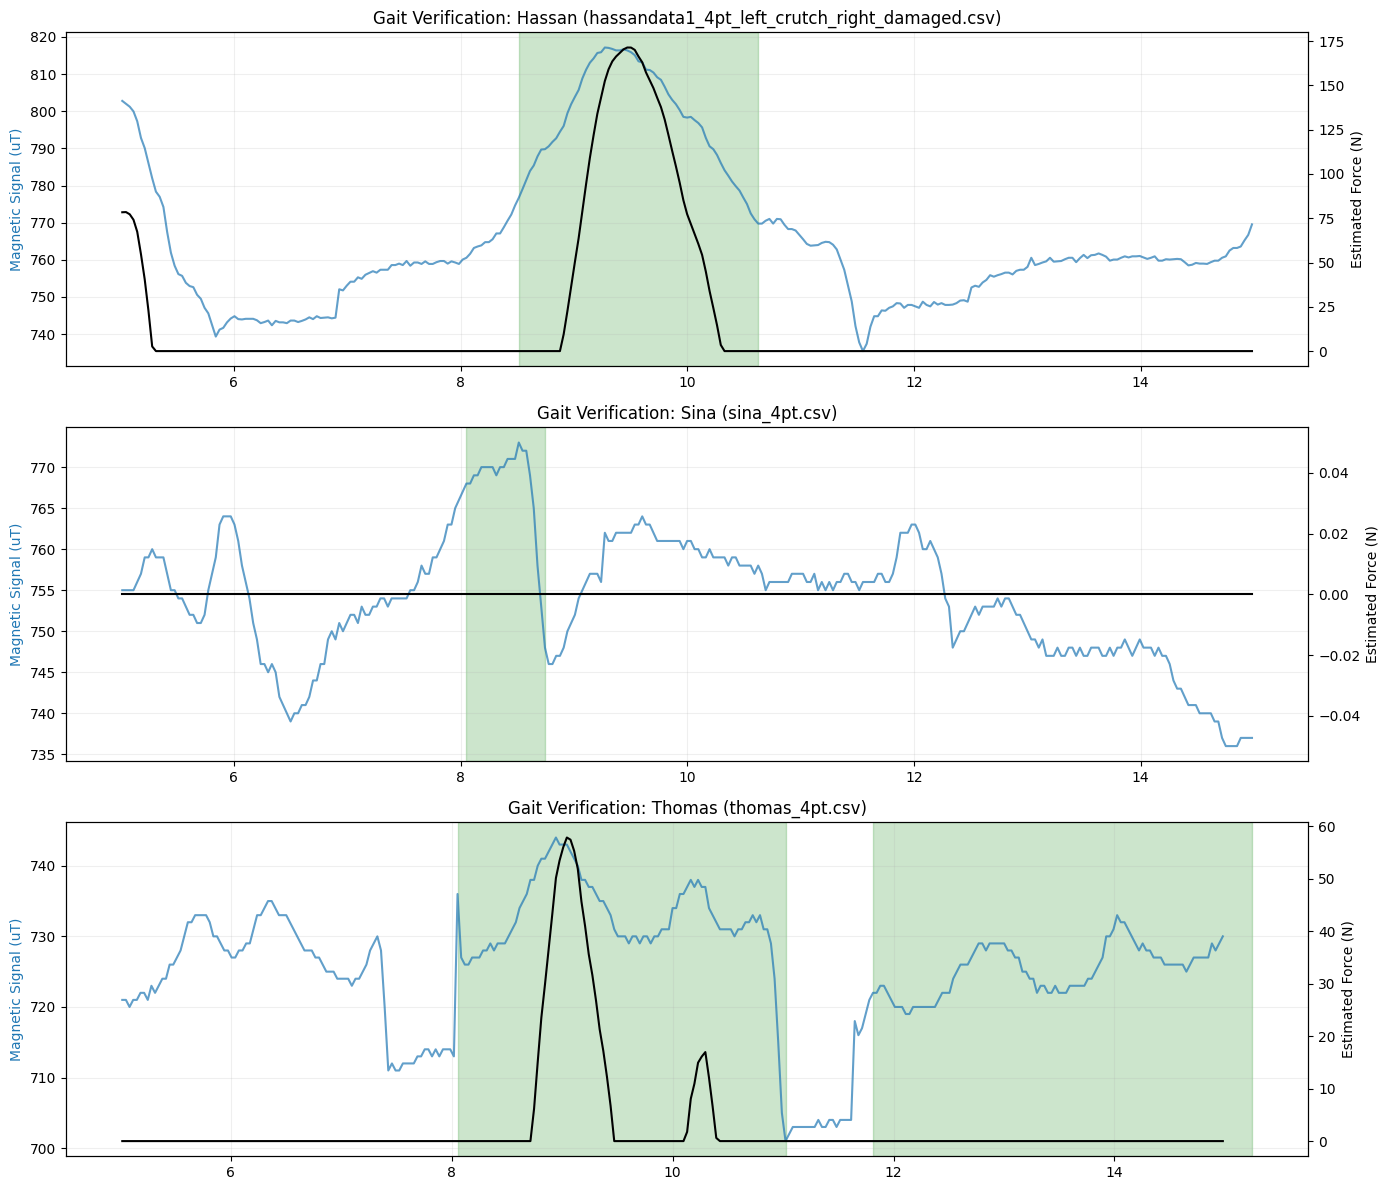

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# --- Constants required for the Rdiff pipeline ---
R_DIFF_ENTER_MM = 0.05
RELEASE_FRACTION = 0.2
REFRACTORY_MS = 100.0
RELEASE_CONFIRM_MS = 50.0
SUSTAINED_CUTOFF_S = 5.0

# Representative gait files for each person (excluding falls)
sample_files = {
    "Hassan": "hassandata1_4pt_left_crutch_right_damaged.csv",
    "Sina": "sina_4pt.csv",
    "Thomas": "thomas_4pt.csv"
}

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for i, (person, fname) in enumerate(sample_files.items()):
    path = Path(fname)
    if not path.exists():
        axs[i].text(0.5, 0.5, f"File {fname} not found", ha='center')
        continue

    # 1. Load and Process
    df_raw, _ = load_hassan_capture_csv(path)
    df_force, _ = add_force_columns(df_raw)
    # Now using the pipeline function defined in cell HMacdcN753GM
    df_det, df_ev = run_rdiff_pipeline(df_force)

    # 2. Zoom to a 10-second window (5s to 15s) for clear stride visualization
    t_start, t_end = 5.0, 15.0
    mask = (df_det['time_s'] >= t_start) & (df_det['time_s'] <= t_end)
    df_zoom = df_det[mask]

    # 3. Plot Signals
    ax_twin = axs[i].twinx()
    ln1 = axs[i].plot(df_zoom['time_s'], df_zoom['mz_uT'], color='C0', alpha=0.7, label='mz_uT (Mag)')
    ln2 = ax_twin.plot(df_zoom['time_s'], df_zoom['force_n'], color='black', lw=1.5, label='Force (N)')

    # 4. Overlay Stance Spans
    if not df_ev.empty:
        zoom_evs = df_ev[(df_ev['start_s'] >= t_start - 1) & (df_ev['release_s'] <= t_end + 1)]
        for _, ev in zoom_evs.iterrows():
            if ev['accepted']:
                color = 'green' if ev['kind'] == 'step' else 'orange'
                axs[i].axvspan(ev['start_s'], ev['release_s'], color=color, alpha=0.2)

    axs[i].set_title(f"Gait Verification: {person} ({fname})")
    axs[i].set_ylabel("Magnetic Signal (uT)", color='C0')
    ax_twin.set_ylabel("Estimated Force (N)", color='black')
    axs[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
def compare_pipelines_head_to_head():
    results = []
    for subject, fname in sample_files.items():
        path = Path(fname)
        if not path.exists(): continue

        # 1. Load Data
        df_raw, _ = load_hassan_capture_csv(path)
        df_force, _ = add_force_columns(df_raw)

        # 2. Run Magnetic Pipeline (using existing function or equivalent logic)
        # Note: run_peak_release_pipeline is our standard Z-score model
        _, ev_mag = run_peak_release_pipeline(df_force)

        # 3. Run r_diff Pipeline
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        # 4. Aggregate Metrics
        results.append({
            'Subject': subject,
            'Pipeline': 'Magnetic (Z=2.0)',
            'Steps': len(ev_mag[ev_mag['accepted'] & (ev_mag['kind'] == 'step')]),
            'Sustained': len(ev_mag[ev_mag['accepted'] & (ev_mag['kind'] == 'sustained')]),
            'Avg Duration (s)': ev_mag.loc[ev_mag['accepted'], 'duration_s'].mean() if not ev_mag.empty else 0
        })
        results.append({
            'Subject': subject,
            'Pipeline': 'Displacement (2mm)',
            'Steps': len(ev_rdiff[ev_rdiff['accepted'] & (ev_rdiff['kind'] == 'step')]),
            'Sustained': len(ev_rdiff[ev_rdiff['accepted'] & (ev_rdiff['kind'] == 'sustained')]),
            'Avg Duration (s)': ev_rdiff.loc[ev_rdiff['accepted'], 'duration_s'].mean() if not ev_rdiff.empty else 0
        })

    comparison_df = pd.DataFrame(results)
    display(comparison_df.pivot(index='Subject', columns='Pipeline', values=['Steps', 'Avg Duration (s)']))
    return comparison_df

comparison_results = compare_pipelines_head_to_head()

Steps                    Avg Duration (s)  \
Pipeline Displacement (2mm) Magnetic (Z=2.0) Displacement (2mm)   
Subject                                                           
Hassan                 10.0              3.0           1.395900   
Sina                    5.0              6.0           0.963600   
Thomas                  6.0              1.0           3.790875   

                           
Pipeline Magnetic (Z=2.0)  
Subject                    
Hassan           3.102000  
Sina             2.901938  
Thomas           4.799143

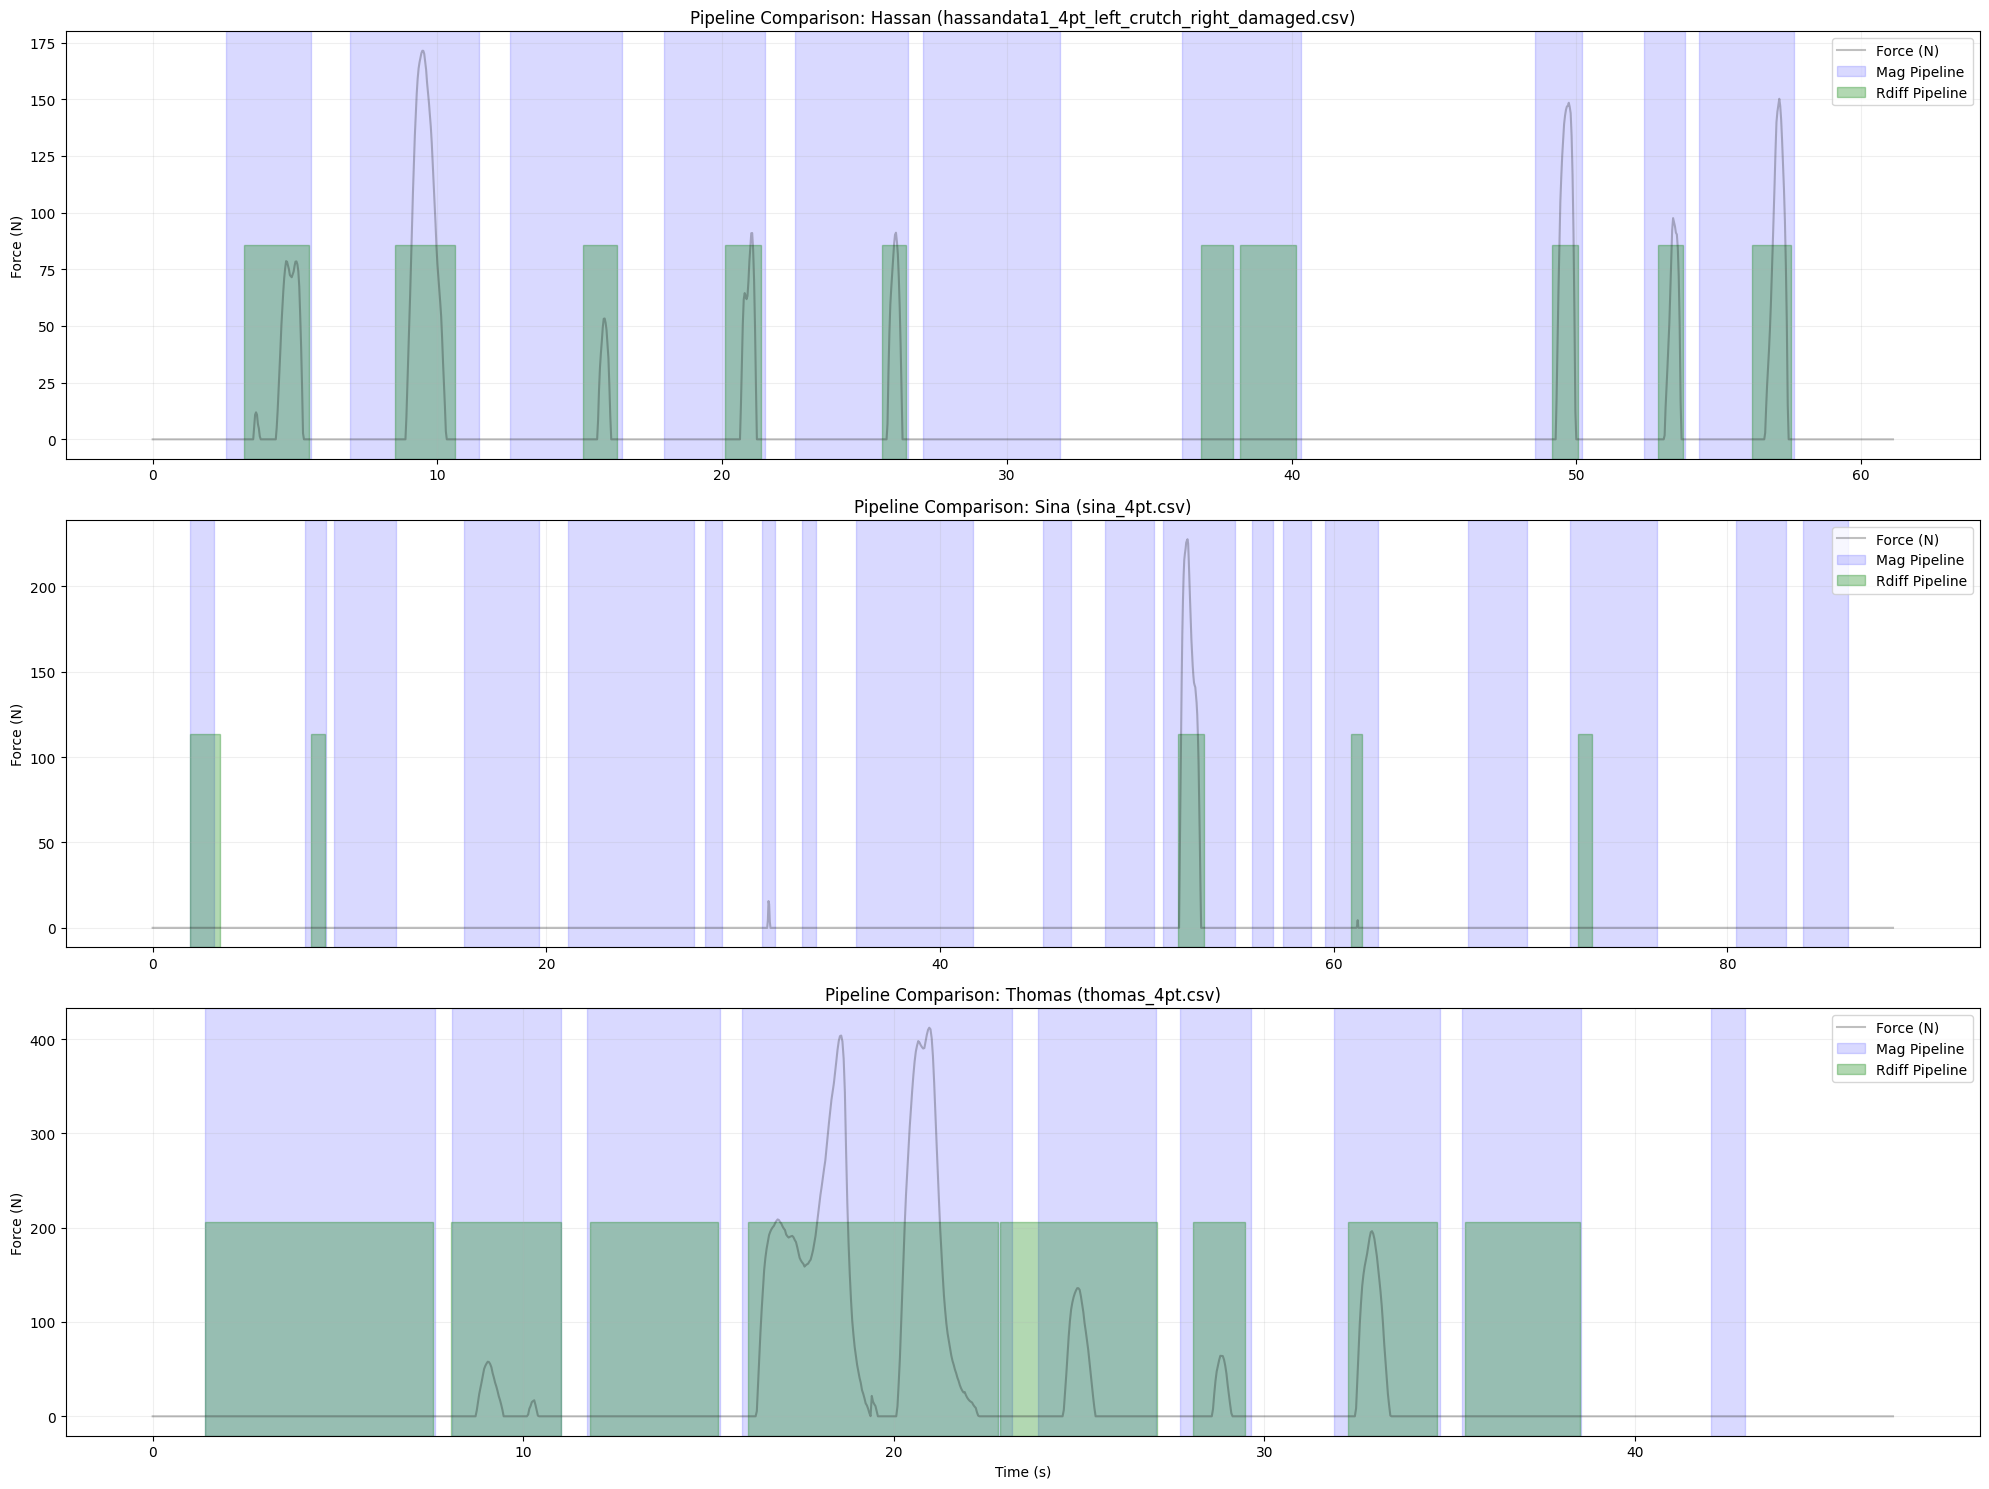

In [ ]:
def plot_all_pipelines_comparison(subjects=["Hassan", "Sina", "Thomas"]):
    fig, axs = plt.subplots(len(subjects), 1, figsize=(20, 5 * len(subjects)), sharex=False)

    for i, person in enumerate(subjects):
        fname = sample_files[person]
        df_raw, _ = load_hassan_capture_csv(Path(fname))
        df_force, _ = add_force_columns(df_raw)

        # Run both pipelines
        _, ev_mag = run_peak_release_pipeline(df_force)
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        t = df_force['time_s']
        axs[i].plot(t, df_force['force_n'], color='black', alpha=0.25, label='Force (N)')

        # Overlay Magnetic (Blue)
        first_mag = True
        for _, ev in ev_mag[ev_mag['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], color='blue', alpha=0.15,
                           label='Mag Pipeline' if first_mag else "")
            first_mag = False

        # Overlay Rdiff (Green)
        first_rdiff = True
        for _, ev in ev_rdiff[ev_rdiff['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.5, color='green', alpha=0.3,
                           label='Rdiff Pipeline' if first_rdiff else "")
            first_rdiff = False

        axs[i].set_title(f"Pipeline Comparison: {person} ({fname})")
        axs[i].set_ylabel("Force (N)")
        axs[i].legend(loc='upper right')
        axs[i].grid(True, alpha=0.2)

    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_all_pipelines_comparison()

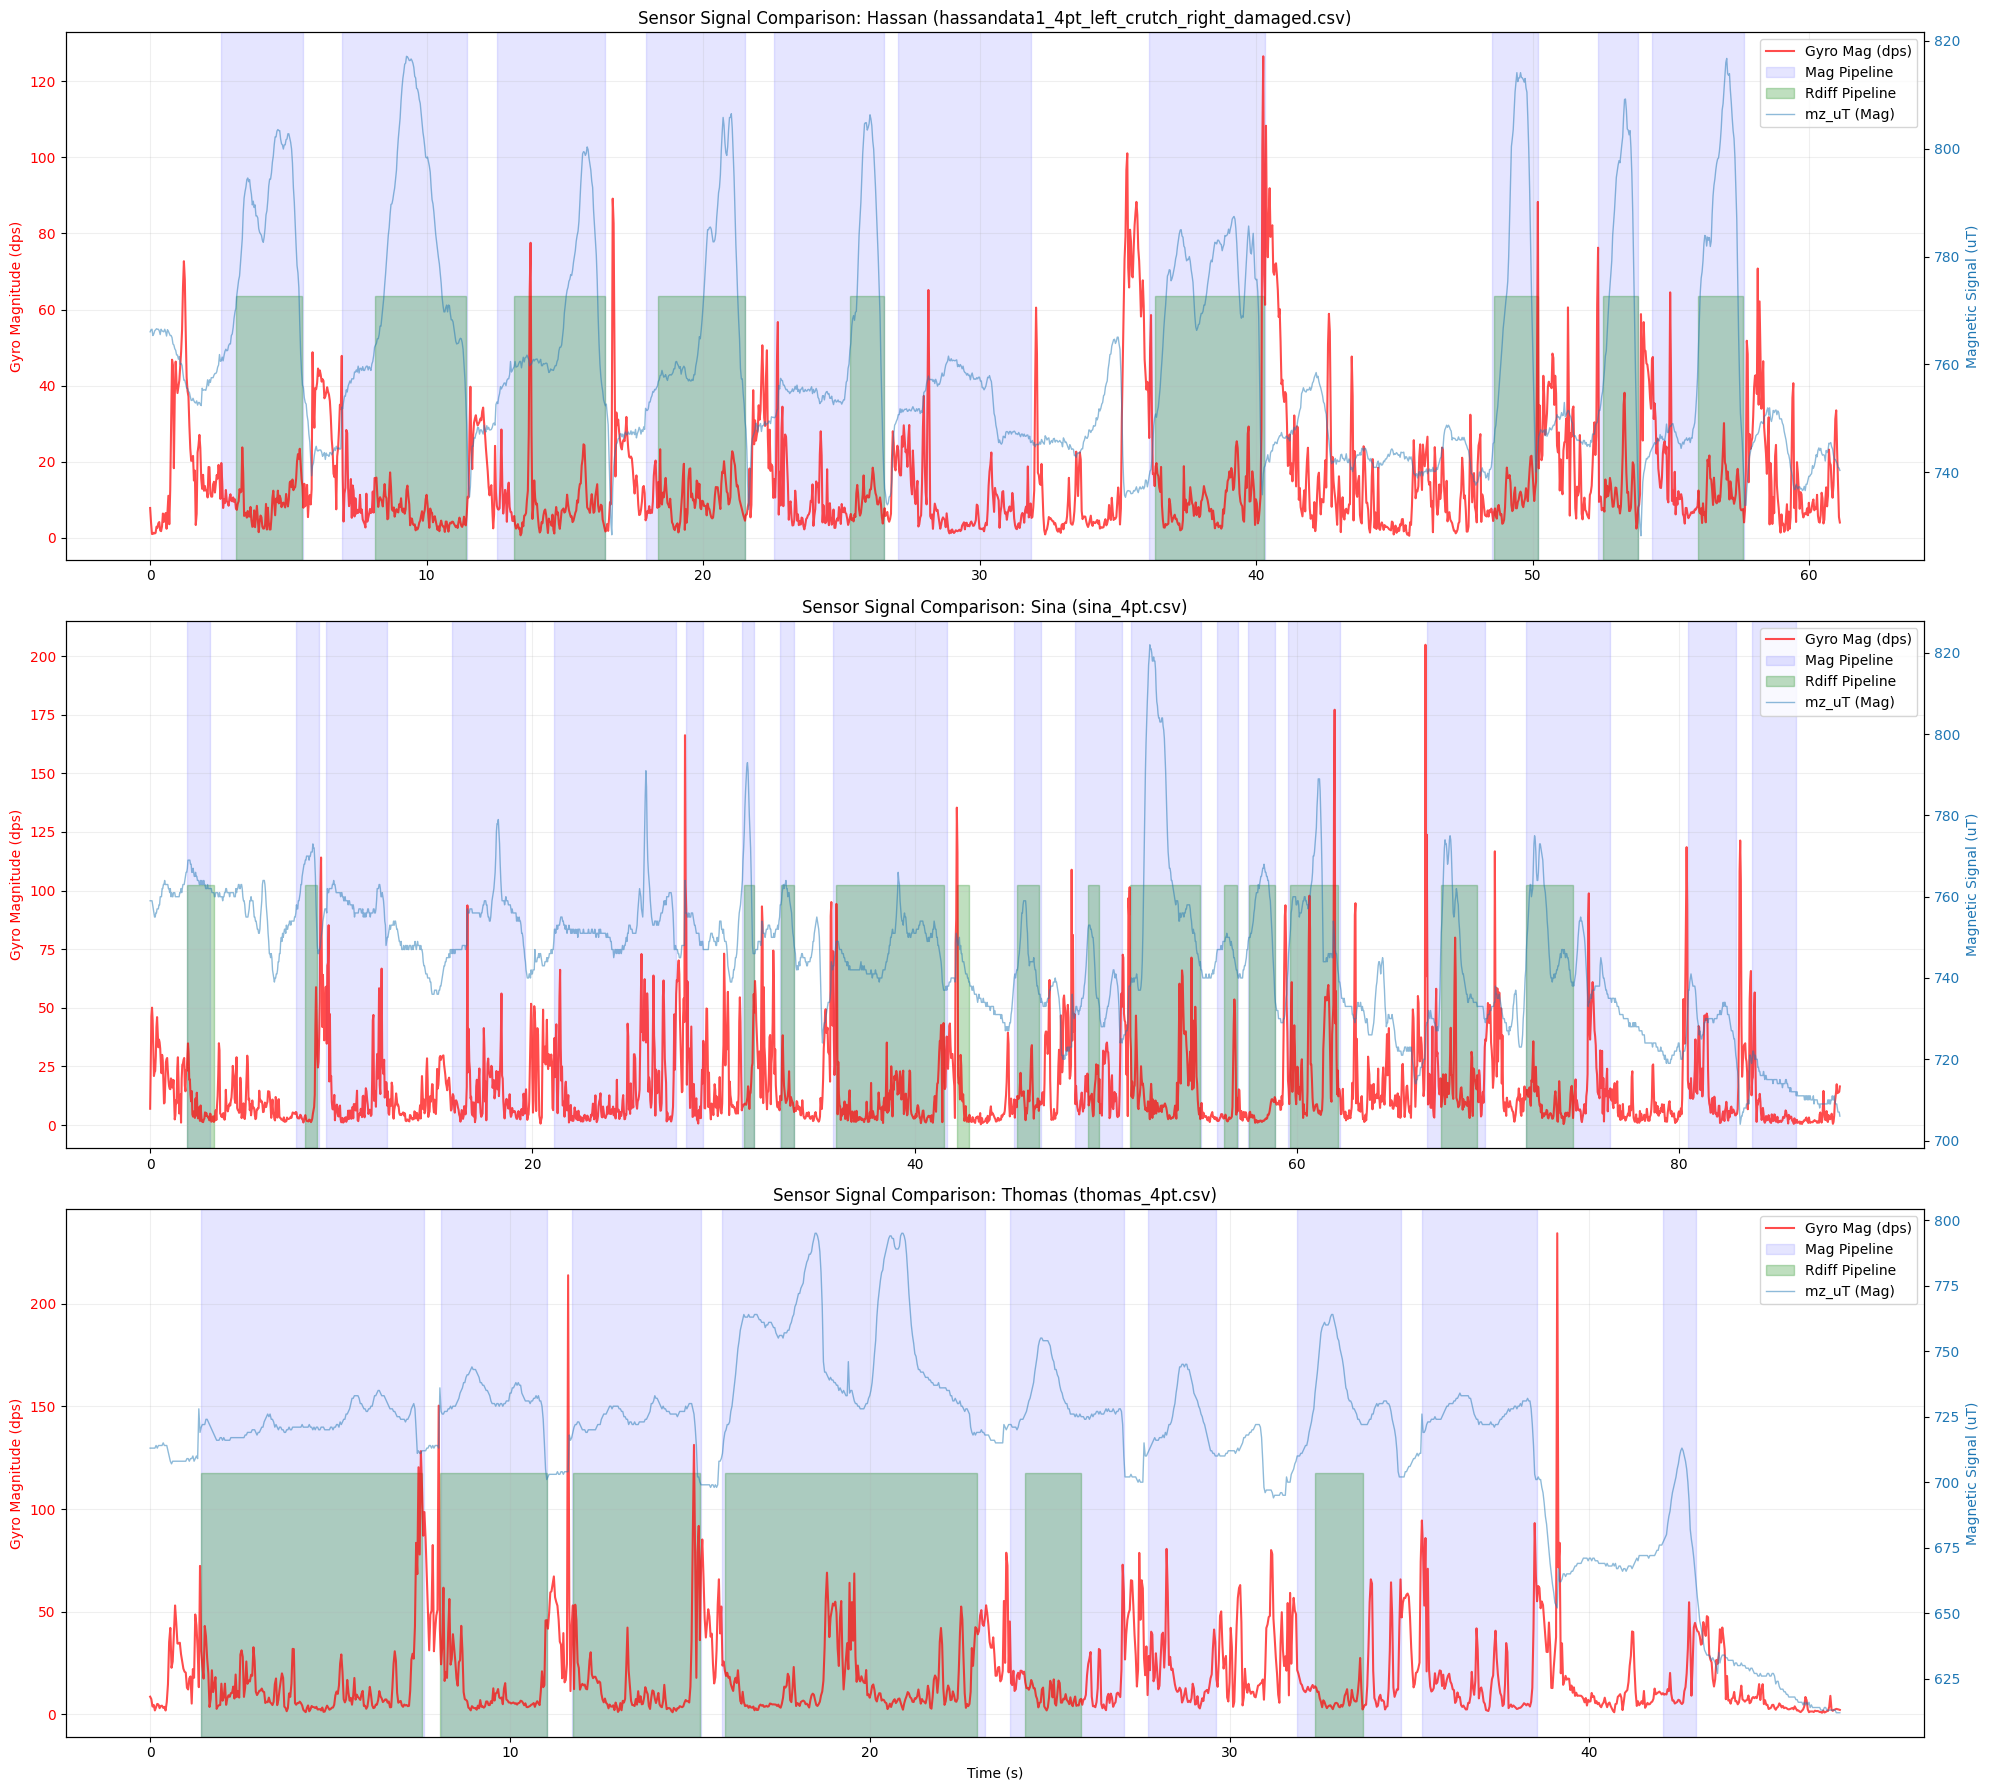

In [ ]:
def plot_all_pipelines_comparison_with_mz(subjects=["Hassan", "Sina", "Thomas"]):
    fig, axs = plt.subplots(len(subjects), 1, figsize=(20, 6 * len(subjects)), sharex=False)

    for i, person in enumerate(subjects):
        fname = sample_files[person]
        df_raw, _ = load_hassan_capture_csv(Path(fname))
        df_force, _ = add_force_columns(df_raw)

        # Run both pipelines for span overlays
        _, ev_mag = run_peak_release_pipeline(df_force)
        _, ev_rdiff = run_peak_release_pipeline_magnet_only(df_force)

        t = df_force['time_s']

        # Primary Axis: Gyro Magnitude in Red
        axs[i].plot(t, df_force['gyro_mag_dps'], color='red', alpha=0.7, lw=1.5, label='Gyro Mag (dps)')
        axs[i].set_ylabel("Gyro Magnitude (dps)", color='red')
        axs[i].tick_params(axis='y', labelcolor='red')

        # Secondary Axis: Magnetic Signal (mz)
        ax_sec = axs[i].twinx()
        ax_sec.plot(t, df_force['mz_uT'], color='C0', alpha=0.5, lw=1, label='mz_uT (Mag)')

        ax_sec.set_ylabel("Magnetic Signal (uT)", color='C0')
        ax_sec.tick_params(axis='y', labelcolor='C0')

        # Overlay Magnetic Spans (Blue)
        first_mag = True
        for _, ev in ev_mag[ev_mag['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], color='blue', alpha=0.1,
                           label='Mag Pipeline' if first_mag else "")
            first_mag = False

        # Overlay Rdiff Spans (Green)
        first_rdiff = True
        for _, ev in ev_rdiff[ev_rdiff['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.5, color='green', alpha=0.25,
                           label='Rdiff Pipeline' if first_rdiff else "")
            first_rdiff = False

        axs[i].set_title(f"Sensor Signal Comparison: {person} ({fname})")

        # Combine legends
        lines, labels = axs[i].get_legend_handles_labels()
        lines2, labels2 = ax_sec.get_legend_handles_labels()
        axs[i].legend(lines + lines2, labels + labels2, loc='upper right')
        axs[i].grid(True, alpha=0.2)

    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_all_pipelines_comparison_with_mz()

In [ ]:
def compare_three_pipelines_head_to_head():
    results = []
    for subject, fname in sample_files.items():
        path = Path(fname)
        if not path.exists(): continue

        # 1. Load and prepare data
        df_raw, _ = load_hassan_capture_csv(path)
        df_force, _ = add_force_columns(df_raw)

        # 2. Run All Three Pipelines
        _, ev_mag = run_peak_release_pipeline(df_force) # Hard Z=2.0
        _, ev_rdiff = run_rdiff_pipeline(df_force)      # Displacement 2mm
        _, ev_corr = corroborated_pipeline(df_force)    # Soft Z=1.0 + Sensor Corr

        pipelines = [
            ('Magnetic (Z=2.0)', ev_mag),
            ('Displacement (2mm)', ev_rdiff),
            ('Corroborated (Z=1.0+Sens)', ev_corr)
        ]

        for name, ev_df in pipelines:
            results.append({
                'Subject': subject,
                'Pipeline': name,
                'Steps': len(ev_df[ev_df['accepted'] & (ev_df['kind'] == 'step')]) if not ev_df.empty else 0,
                'Sustained': len(ev_df[ev_df['accepted'] & (ev_df['kind'] == 'sustained')]) if not ev_df.empty else 0,
                'Avg Duration (s)': ev_df.loc[ev_df['accepted'], 'duration_s'].mean() if not ev_df.empty else 0
            })

    comparison_df = pd.DataFrame(results)
    # Pivot for clean comparison
    table = comparison_df.pivot(index='Subject', columns='Pipeline', values='Steps')
    display(table)
    return comparison_df

comparison_3_results = compare_three_pipelines_head_to_head()

Pipeline,Corroborated (Z=1.0+Sens),Displacement (2mm),Magnetic (Z=2.0)
Subject,,,
Hassan,9,10,9
Sina,18,5,13
Thomas,5,6,4


NameError: name 'subject_registry' is not defined

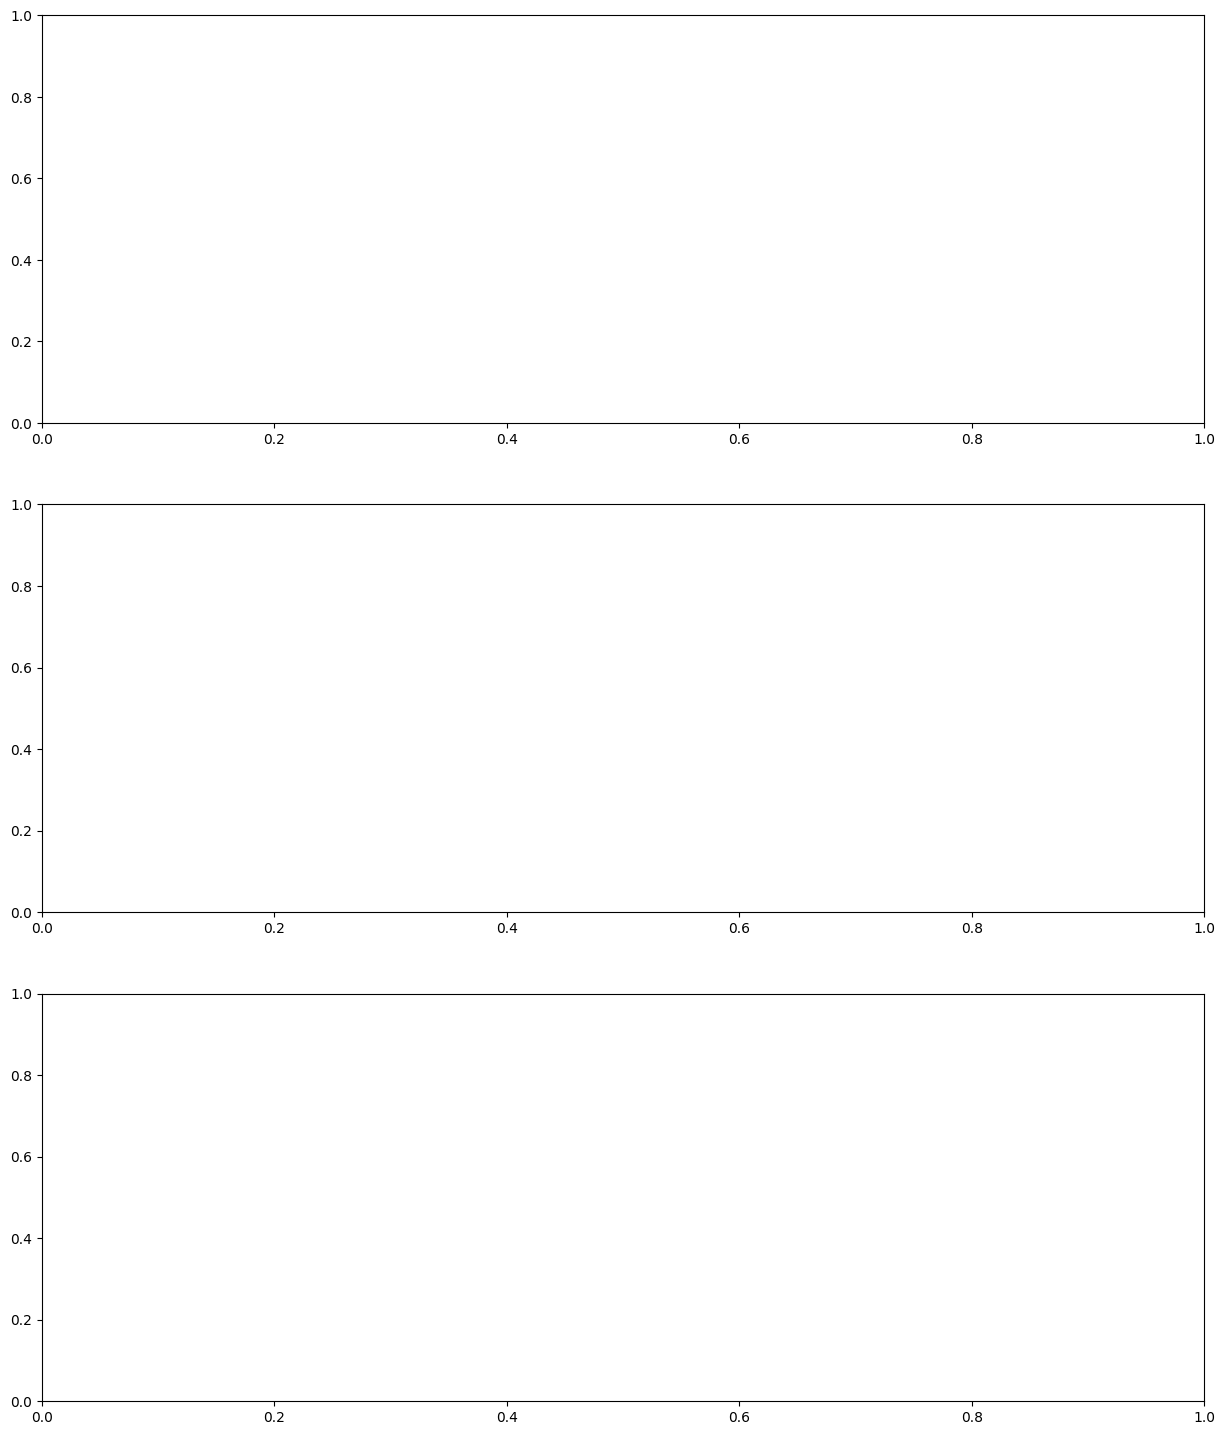

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

def plot_4pt_comparison_with_mz():
    subjects = ["Hassan", "Sina", "Thomas"]
    fig, axs = plt.subplots(len(subjects), 1, figsize=(15, 6 * len(subjects)), sharex=False)

    for i, person in enumerate(subjects):
        # Find the 4pt file for this subject
        match_file = None
        for fname, (p, g) in subject_registry.items():
            if p == person and g == "4pt":
                match_file = fname
                break

        if not match_file or not Path(match_file).exists():
            axs[i].text(0.5, 0.5, f"No 4pt file for {person}", ha='center')
            continue

        # Load and process
        df_raw, _ = load_hassan_capture_csv(Path(match_file))
        df_force, _ = add_force_columns(df_raw)

        # Run Pipelines
        _, ev_mag = run_peak_release_pipeline(df_force)
        _, ev_rdiff = run_rdiff_pipeline(df_force)
        _, ev_corr = corroborated_pipeline(df_force)

        t = df_force['time_s']

        # Primary Axis: Force
        ln1 = axs[i].plot(t, df_force['force_n'], color='black', alpha=0.4, lw=1.5, label='Force (N)')
        axs[i].set_ylabel("Estimated Force (N)", color='black')

        # Secondary Axis: Magnetic Signal
        ax_mag = axs[i].twinx()
        ln2 = ax_mag.plot(t, df_force['mz_uT'], color='C0', alpha=0.4, label='mz_uT')
        ax_mag.set_ylabel("Magnetic Signal (mz uT)", color='C0')
        ax_mag.tick_params(axis='y', labelcolor='C0')

        # Overlay Spans
        # Corroborated (Top level - Red)
        for _, ev in ev_corr[ev_corr['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], color='red', alpha=0.1, label='Corr' if _ == 0 else "")

        # Magnetic (Mid level - Blue)
        for _, ev in ev_mag[ev_mag['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.6, color='blue', alpha=0.1, label='Mag' if _ == 0 else "")

        # Displacement (Bottom level - Green)
        for _, ev in ev_rdiff[ev_rdiff['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.3, color='green', alpha=0.2, label='Rdiff' if _ == 0 else "")

        axs[i].set_title(f"{person}: 4-Point Gait Comparison")
        axs[i].grid(True, alpha=0.2)

        # Combined Legend
        lines = ln1 + ln2
        labels = [l.get_label() for l in lines]
        axs[i].legend(lines, labels, loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

plot_4pt_comparison_with_mz()

In [ ]:
def compare_all_gait_types():
    results = []
    # Iterate through the full registry to cover all gait types
    for filename, (person, gait) in subject_registry.items():
        path = Path(filename)
        if not path.exists() or gait == 'fall': continue

        df_raw, _ = load_hassan_capture_csv(path)
        df_force, _ = add_force_columns(df_raw)

        # Run Magnetic Pipeline
        _, ev_mag = run_peak_release_pipeline(df_force)
        # Run Displacement Pipeline
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        for pipe_name, ev_df in [('Magnetic', ev_mag), ('Displacement', ev_rdiff)]:
            results.append({
                'Subject': person,
                'Gait': gait,
                'Pipeline': pipe_name,
                'Steps Detected': len(ev_df[ev_df['accepted'] & (ev_df['kind'] == 'step')]) if not ev_df.empty else 0,
                'Avg Duration': ev_df.loc[ev_df['accepted'], 'duration_s'].mean() if not ev_df.empty else 0
            })

    all_gaits_df = pd.DataFrame(results)
    # Pivot for a clear comparison table
    comparison_table = all_gaits_df.pivot_table(
        index=['Subject', 'Gait'],
        columns='Pipeline',
        values='Steps Detected',
        fill_value=0
    )
    display(comparison_table)
    return all_gaits_df

all_gaits_comparison = compare_all_gait_types()

NameError: name 'subject_registry' is not defined

NameError: name 'R_DIFF_ENTER_MM' is not defined

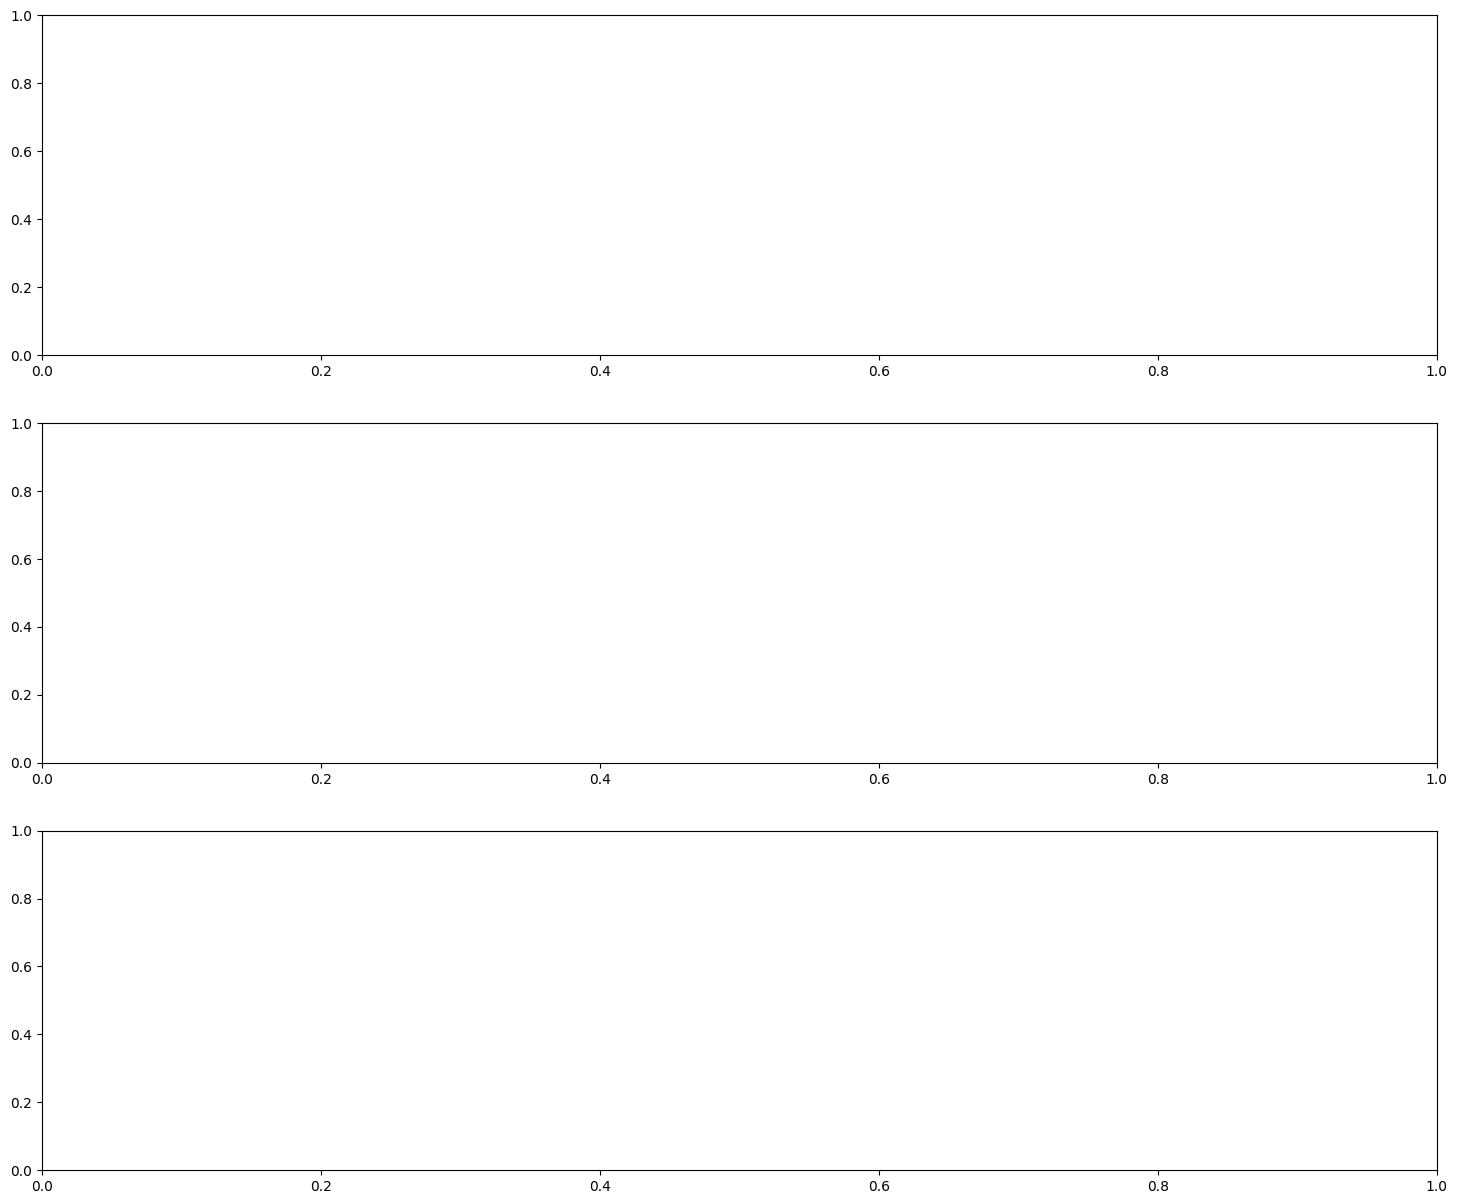

In [ ]:
def plot_swing_gait_comparison():
    swing_files = {
        "Hassan": "hassan3pt_left_crutch_left_damaged.csv",
        "Sina": "3pointsina3.csv",
        "Thomas": "3pointthomas4.csv"
    }

    fig, axs = plt.subplots(3, 1, figsize=(18, 15))

    for i, (person, fname) in enumerate(swing_files.items()):
        path = Path(fname)
        if not path.exists():
            axs[i].set_title(f"{person}: {fname} not found")
            continue

        df_raw, _ = load_hassan_capture_csv(path)
        df_force, _ = add_force_columns(df_raw)

        _, ev_mag = run_peak_release_pipeline(df_force)
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        t = df_force['time_s']
        axs[i].plot(t, df_force['force_n'], color='black', alpha=0.3, label='Estimated Force (N)')

        # Mag Spans
        for _, ev in ev_mag[ev_mag['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], color='blue', alpha=0.1, label='Mag' if _ == ev_mag[ev_mag['accepted']].index[0] else "")

        # Rdiff Spans
        for _, ev in ev_rdiff[ev_rdiff['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.5, color='green', alpha=0.3, label='Rdiff' if _ == ev_rdiff[ev_rdiff['accepted']].index[0] else "")

        axs[i].set_title(f"Swing Gait Comparison: {person} ({fname})")
        axs[i].legend(loc='upper right')
        axs[i].set_ylim(0, df_force['force_n'].max() * 1.1)

    plt.tight_layout()
    plt.show()

plot_swing_gait_comparison()

Meta Model

In [ ]:
def export_sensor_master_no_detection():
    """
    Aggregates sensor and force data for Hassan, Sina, and Thomas.
    Includes 'fall' gait. Excludes all detection/stance/z-score columns.
    """
    master_rows = []

    for filename, (person, gait) in subject_registry.items():
        path = Path(filename)
        if not path.exists():
            continue

        # 1. Load data using the established helper
        raw_df, _ = load_hassan_capture_csv(path)
        if raw_df.empty:
            continue

        # 2. Handle specific column mapping for Thomas/Sina fall files if needed
        if filename in ["tgfall.csv", "tgfall2.csv"]:
            raw_df["mz_uT"] = raw_df.iloc[:, -1]

        # 3. Add Force Estimates (adds r_diff and force_n)
        force_df, _ = add_force_columns(raw_df)

        # 4. Label the data
        force_df['person_id'] = person
        force_df['gait_type'] = gait

        # 5. Define the clean column set (NO step detection columns like 'is_stance', 'state', 'z_score')
        sensor_cols = [
            'person_id', 'gait_type', 'time_s', 'force_n', 'r_diff_mm',
            'ax_g', 'ay_g', 'az_g', 'gx_dps', 'gy_dps', 'gz_dps',
            'mx_uT', 'my_uT', 'mz_uT', 'roll_deg', 'pitch_deg', 'yaw_deg'
        ]

        # Only keep existing columns from the list
        existing_cols = [c for c in sensor_cols if c in force_df.columns]
        master_rows.append(force_df[existing_cols])

    # Combine all into one master table
    sensor_master_df = pd.concat(master_rows, ignore_index=True)

    # Save to CSV
    sensor_master_df.to_csv("sensor_only_master.csv", index=False)
    print(f"Success! Created master dataset with {len(sensor_master_df)} rows.")
    return sensor_master_df

# Run the function and show summary
sensor_data_df = export_sensor_master_no_detection()
display(sensor_data_df.head())
display(sensor_data_df.groupby(['person_id', 'gait_type']).size().unstack(fill_value=0))

Success! Created master dataset with 22293 rows.


,person_id,gait_type,time_s,force_n,r_diff_mm,ax_g,ay_g,az_g,gx_dps,gy_dps,gz_dps,mx_uT,my_uT,mz_uT,roll_deg,pitch_deg,yaw_deg
0,Hassan,swing,0.000,0.0,0.044495,-0.9941,-0.1259,0.0239,-0.98,-0.35,1.82,104.69,3.26,732.26,-130.64,85.90,121.33
1,Hassan,swing,0.033,0.0,0.043160,-0.9955,-0.1264,0.0205,-0.49,-0.70,2.03,104.69,3.26,731.79,-126.74,85.92,125.24
2,Hassan,swing,0.066,0.0,0.041903,-0.9945,-0.1220,0.0234,-0.91,-0.70,2.17,105.05,2.90,731.70,-122.88,85.94,129.12
3,Hassan,swing,0.099,0.0,0.040960,-0.9975,-0.1274,0.0259,0.28,-0.70,2.10,104.32,3.26,731.70,-118.94,85.93,133.04
4,Hassan,swing,0.132,0.0,0.040253,-0.9960,-0.1249,0.0283,3.92,-0.56,1.82,104.68,3.26,731.70,-114.91,85.90,136.92


gait_type,2pt,3pt,4pt,fall,swing
person_id,,,,,
Hassan,1101,1408,1853,0,952
Sina,1961,4127,2680,0,1549
Thomas,1318,2296,1424,452,1172


Success! Collated 22293 rows of continuous data.


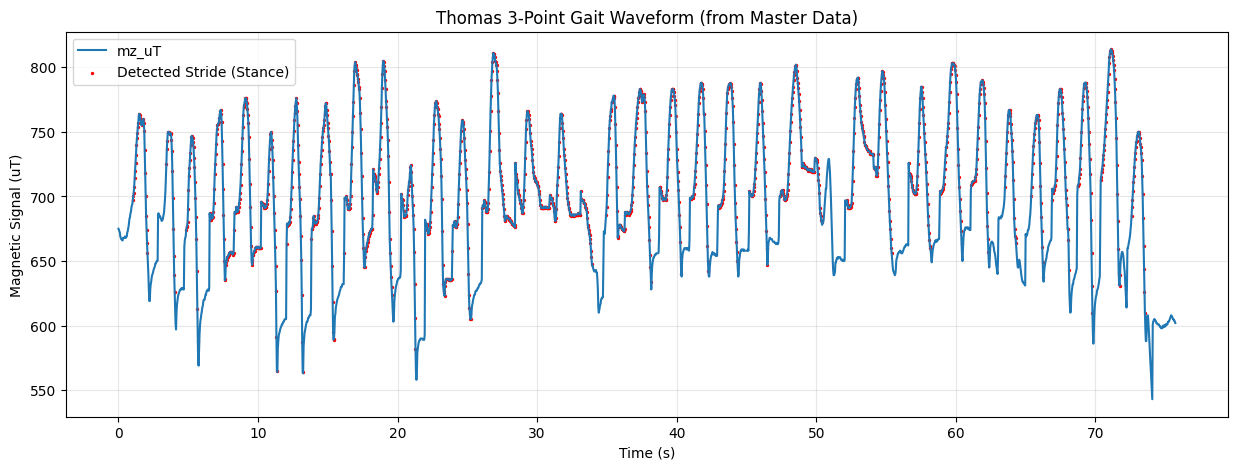

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

all_processed_data = []

# subject_registry contains mappings for Hassan, Sina, and Thomas files
for filename, (person, gait) in subject_registry.items():
    path_obj = Path(filename)
    if not path_obj.exists():
        continue

    # 1. Load data
    raw_df, _ = load_hassan_capture_csv(path_obj)
    if raw_df.empty: continue

    # 2. Add required force/signal columns
    force_df, _ = add_force_columns(raw_df)

    # 3. Run the Magnetometer-only Pipeline
    detected_df, events_df = run_peak_release_pipeline_magnet_only(force_df)

    # 4. Process and Label
    temp_df = detected_df.copy()
    temp_df['person_id'] = person
    temp_df['gait_type'] = gait
    temp_df['stride_id'] = np.nan

    if not events_df.empty:
        accepted_strides = events_df[events_df['accepted']].copy()
        for i, event in enumerate(accepted_strides.itertuples()):
            # Labeling strides numerically within this file (will be offset later if needed)
            mask = (temp_df['time_s'] >= event.start_s) & (temp_df['time_s'] <= event.release_s)
            temp_df.loc[mask, 'stride_id'] = i + 1

    all_processed_data.append(temp_df)

# Combine everything back into the continuous master dataset
if all_processed_data:
    stride_master_df = pd.concat(all_processed_data, ignore_index=True)

    # Save result
    stride_master_df.to_csv("collated_strides_full_waveform.csv", index=False)
    print(f"Success! Collated {len(stride_master_df)} rows of continuous data.")

    # 5. Plot Thomas 3pt from the master dataframe
    thomas_3pt = stride_master_df[(stride_master_df['person_id'] == 'Thomas') & (stride_master_df['gait_type'] == '3pt')]

    if not thomas_3pt.empty:
        plt.figure(figsize=(15, 5))
        plt.plot(thomas_3pt['time_s'], thomas_3pt['mz_uT'], label='mz_uT')

        # Highlight areas where stride_id is not NaN
        stride_indices = thomas_3pt[thomas_3pt['stride_id'].notna()]
        plt.scatter(stride_indices['time_s'], stride_indices['mz_uT'], color='red', s=2, label='Detected Stride (Stance)')

        plt.title("Thomas 3-Point Gait Waveform (from Master Data)")
        plt.xlabel("Time (s)")
        plt.ylabel("Magnetic Signal (uT)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("No data found to collate.")

In [ ]:
import pandas as pd

# Quick diagnostic check on the current master dataframe
if 'stride_master_df' in globals():
    total_rows = len(stride_master_df)
    # Check for rows where stride_id might have been applied to non-stride data
    # or if the time stamps are continuous (which would mean we didn't discard the 'non-green' parts)
    unique_strides = stride_master_df['stride_id'].nunique()
    avg_rows_per_stride = total_rows / unique_strides if unique_strides > 0 else 0

    print(f"Master Data Check:")
    print(f"- Total Rows: {total_rows}")
    print(f"- Unique Stride IDs: {unique_strides}")
    print(f"- Avg Rows per Stride: {avg_rows_per_stride:.2f}")

    # Display a sample of the transition between two strides to see if there is a jump in time
    if unique_strides > 1:
        sample_strides = stride_master_df[stride_master_df['stride_id'].isin([1, 2])]
        display(sample_strides.tail(5))
else:
    print("stride_master_df not found. Please run the collation cell first.")

Master Data Check:
- Total Rows: 10370
- Unique Stride IDs: 183
- Avg Rows per Stride: 56.67


,person_id,gait_type,stride_id,time_s,seq,timestamp_ms,ax_g,ay_g,az_g,gx_dps,...,detector_signal_lpf_uT,r_mm,r_diff_mm,force_n,state,baseline_mean,baseline_std,z_score,release_level,peak_signal_uT
52,Hassan,swing,2,4.488,5960,530831.0,-0.9848,-0.0820,0.2328,26.46,...,759.605802,24.652372,0.347628,55.482765,loaded,736.824723,4.796539,4.749483,750.987218,807.637197
53,Hassan,swing,2,4.521,5961,530864.0,-0.9179,0.0210,0.3499,41.93,...,755.946852,24.692082,0.307918,29.325579,loaded,736.824723,4.796539,3.986651,750.987218,807.637197
54,Hassan,swing,2,4.554,5962,530897.0,-0.9370,-0.0737,0.3616,59.99,...,753.345139,24.720474,0.279526,10.623485,loaded,736.824723,4.796539,3.444237,750.987218,807.637197
55,Hassan,swing,2,4.587,5963,530930.0,-0.9394,0.0527,0.3709,79.87,...,751.198854,24.743995,0.256005,0.000000,loaded,736.824723,4.796539,2.996771,750.987218,807.637197
56,Hassan,swing,2,4.620,5964,530963.0,-0.9394,0.1186,0.3426,53.69,...,749.079141,24.767313,0.232687,0.000000,releasing,736.824723,4.796539,2.554846,750.987218,807.637197


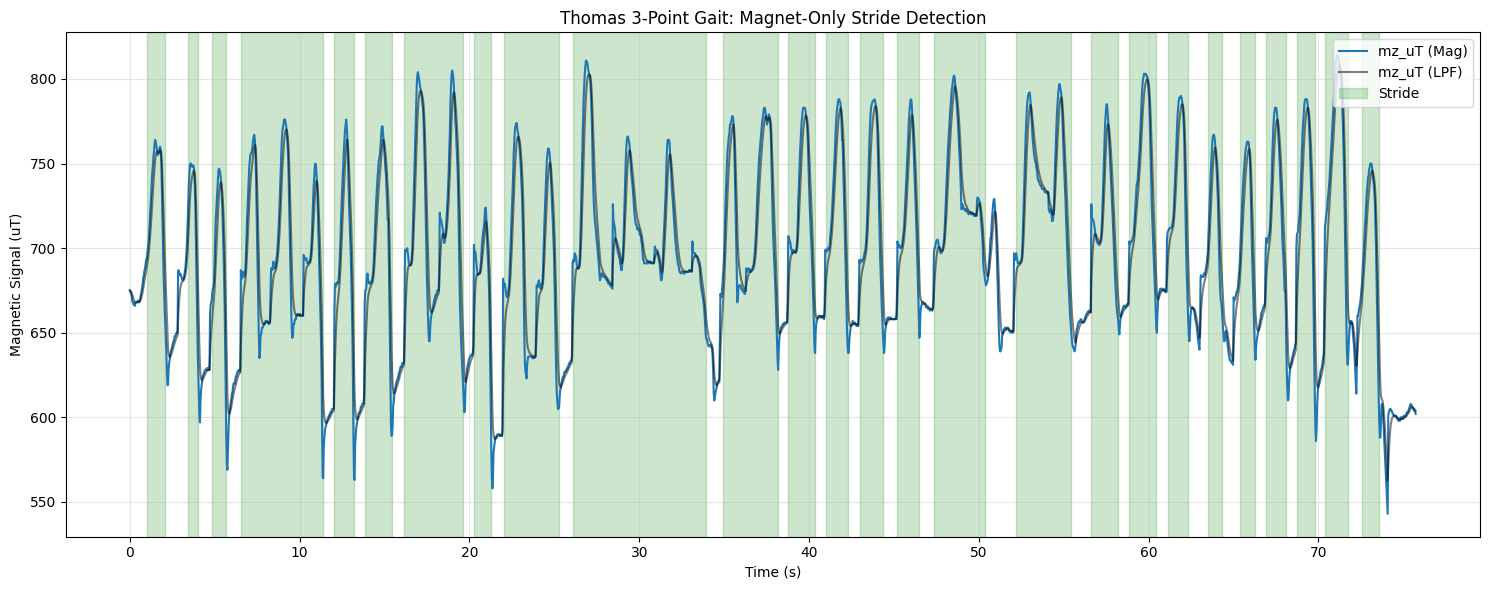

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

def plot_thomas_3pt_magnet_only():
    # Identify the Thomas 3pt file
    fname = "3pointthomas4.csv"
    path = Path(fname)

    if not path.exists():
        print(f"Error: {fname} not found.")
        return

    # 1. Load and Process
    raw_df, _ = load_hassan_capture_csv(path)
    force_df, _ = add_force_columns(raw_df)

    # 2. Run the Magnet-Only Pipeline
    # This uses the function from cell TmXD9vwwCH8J
    detected_df, events_df = run_peak_release_pipeline_magnet_only(force_df)

    # 3. Visualization
    fig, ax = plt.subplots(1, 1, figsize=(15, 6))

    # Plot Magnetometer Z signal
    ax.plot(detected_df['time_s'], detected_df['mz_uT'], color='C0', label='mz_uT (Mag)')
    ax.plot(detected_df['time_s'], detected_df['detector_signal_lpf_uT'], color='black', alpha=0.5, label='mz_uT (LPF)')

    # Overlay Stance Spans for accepted strides
    if not events_df.empty:
        accepted = events_df[events_df['accepted']]
        for _, ev in accepted.iterrows():
            ax.axvspan(ev['start_s'], ev['release_s'], color='green', alpha=0.2, label='Stride' if _ == accepted.index[0] else "")

    ax.set_title(f"Thomas 3-Point Gait: Magnet-Only Stride Detection")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Magnetic Signal (uT)")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_thomas_3pt_magnet_only()

# Fall Thresholding

In [ ]:
# How to detect falls.

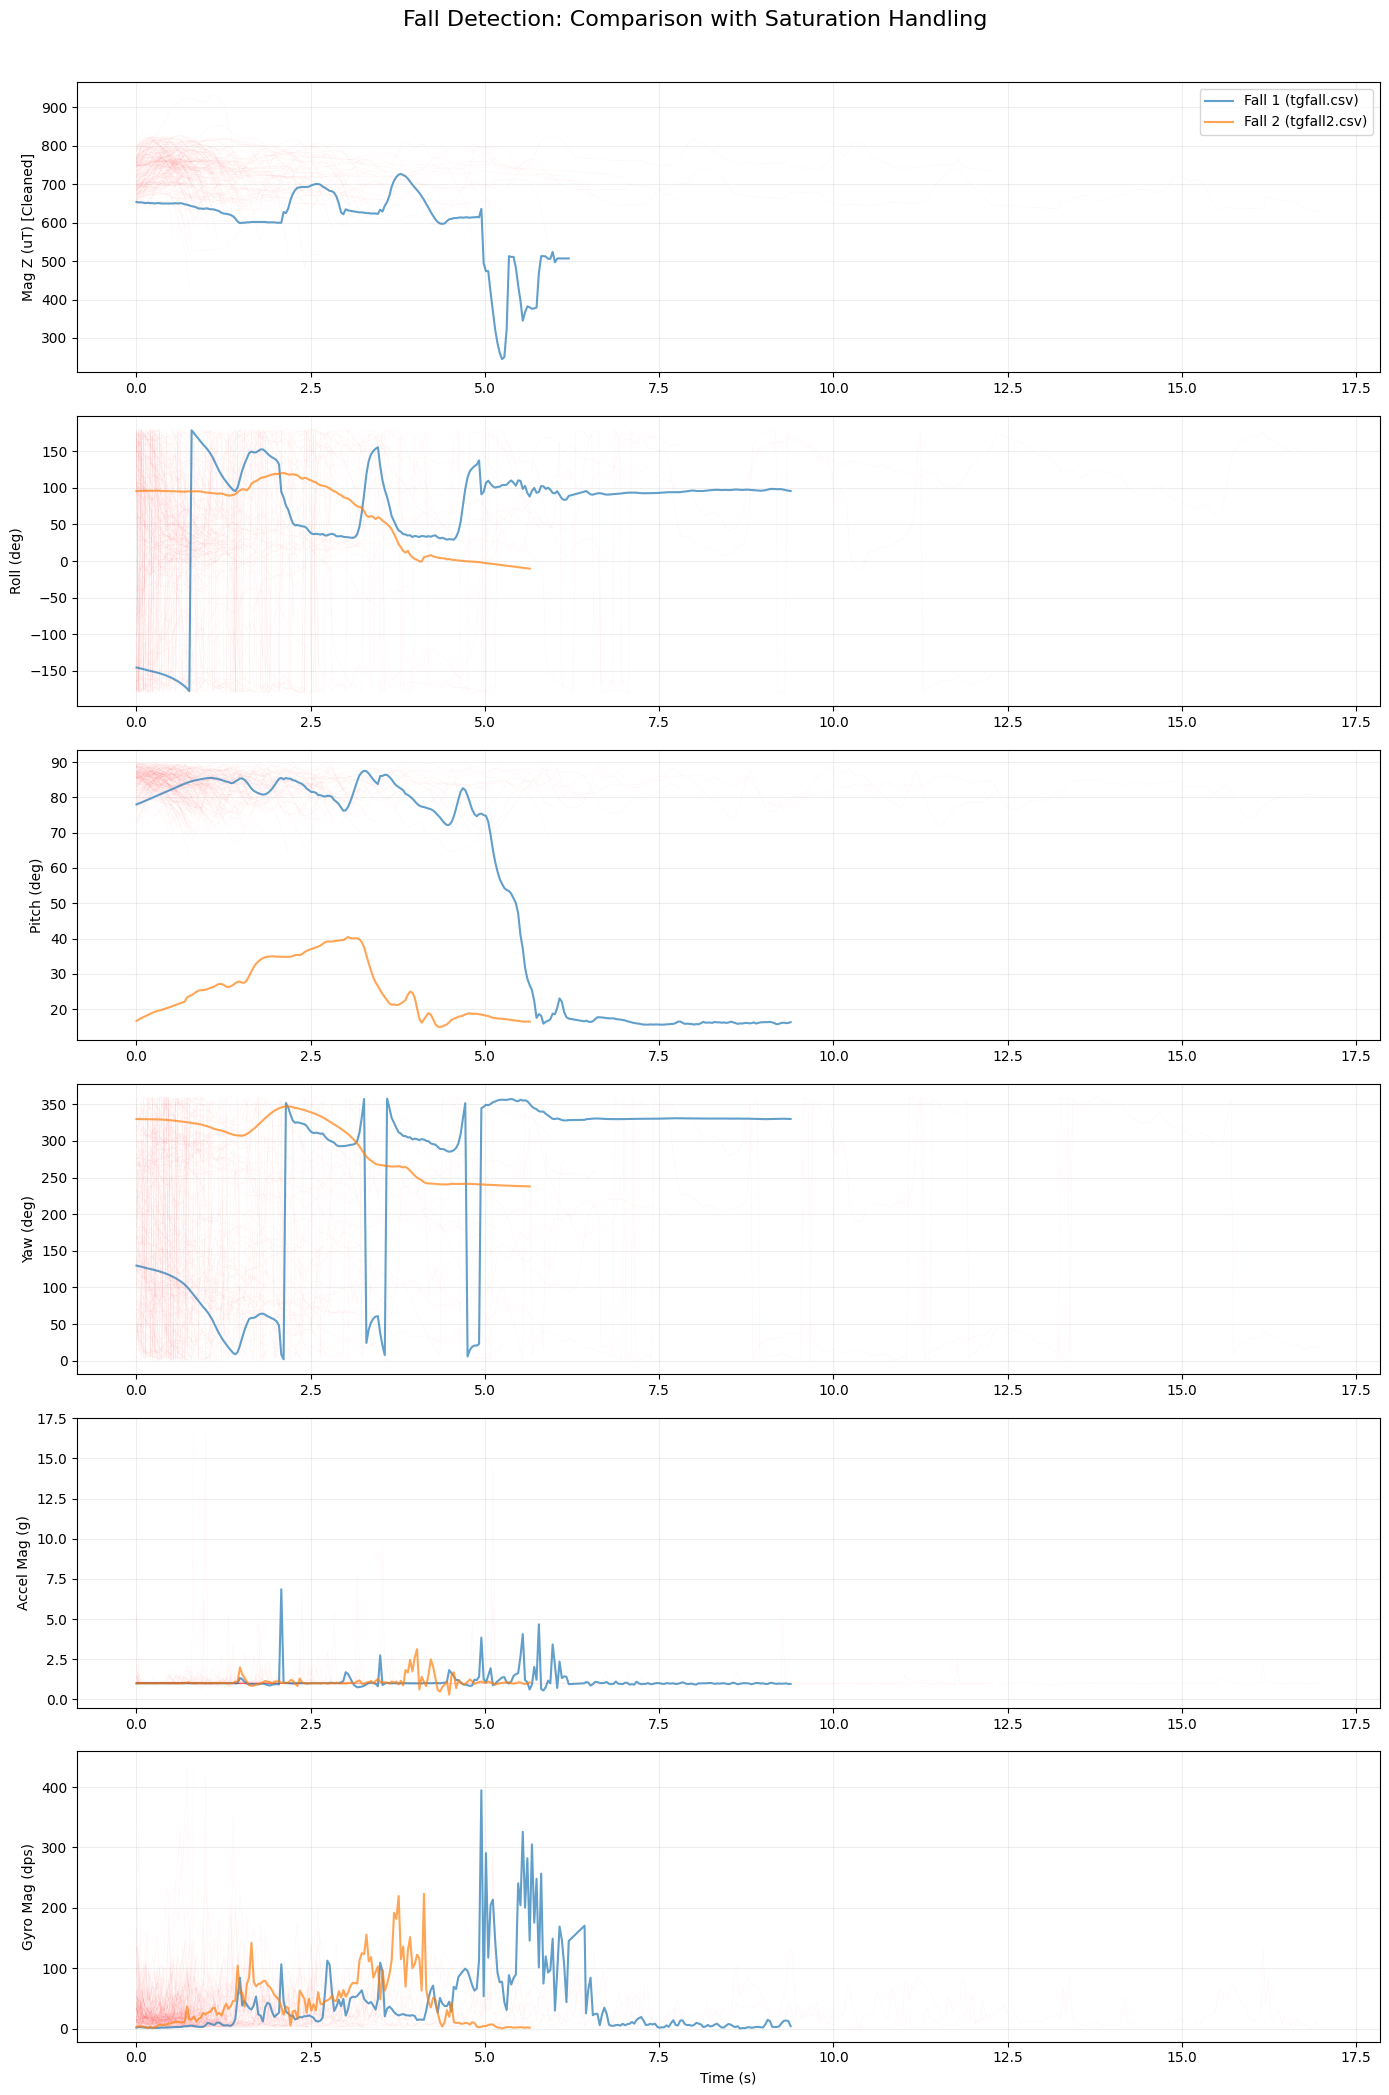

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Load the general comparison data
csv_file = "collated_strides_only.csv"
if not Path(csv_file).exists():
    csv_file = "collated_strides_magnet_only.csv"

df_master = pd.read_csv(csv_file)
others = df_master[df_master['gait_type'] != 'fall']

# 2. Load fall waveforms with saturation check
RAW_CAPTURE_COLS = [
    "seq", "timestamp_ms",
    "ax_g", "ay_g", "az_g",
    "gx_dps", "gy_dps", "gz_dps",
    "roll_deg", "pitch_deg", "yaw_deg",
    "mx_uT", "my_uT", "mz_uT",
]

fall_dfs = []
for f_name in ["tgfall.csv", "tgfall2.csv"]:
    p = Path(f_name)
    if p.exists():
        df = pd.read_csv(p, comment='#', names=RAW_CAPTURE_COLS, header=None if pd.read_csv(p, nrows=1, comment='#').columns[0] != 'seq' else 0)

        # Standardize time
        df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0

        # Handle Z-axis mapping/saturation
        if "mz_uT" not in df.columns or df["mz_uT"].isnull().all():
            df["mz_uT"] = df.iloc[:, -1]

        # Saturation check: -32768 is a common 16-bit overflow limit
        is_saturated = (df["mz_uT"] <= -32000).any()
        if is_saturated:
            print(f"Warning: Saturation detected in {f_name} Mag Z. Clipping values for visualization.")
            # We clip to a visible range or mark as NaN to show the 'flat' issue clearly
            df["mz_uT_clean"] = df["mz_uT"].apply(lambda x: np.nan if x <= -32000 else x)
        else:
            df["mz_uT_clean"] = df["mz_uT"]

        df["accel_mag_g"] = np.sqrt(df["ax_g"]**2 + df["ay_g"]**2 + df["az_g"]**2)
        df["gyro_mag_dps"] = np.sqrt(df["gx_dps"]**2 + df["gy_dps"]**2 + df["gz_dps"]**2)
        df["file_source"] = f_name
        fall_dfs.append(df)

# 3. Visualization
def plot_full_fall_comparison(fall_list, others_df):
    # Mapping for channels to use 'clean' Mag Z if saturation was found
    channels = [
        ('mz_uT_clean', 'Mag Z (uT) [Cleaned]'),
        ('roll_deg', 'Roll (deg)'),
        ('pitch_deg', 'Pitch (deg)'),
        ('yaw_deg', 'Yaw (deg)'),
        ('accel_mag_g', 'Accel Mag (g)'),
        ('gyro_mag_dps', 'Gyro Mag (dps)')
    ]

    fig, axs = plt.subplots(len(channels), 1, figsize=(14, 22), sharex=False)

    for i, (col, label) in enumerate(channels):
        for s_id in others_df['stride_id'].unique():
            stride = others_df[others_df['stride_id'] == s_id]
            t_norm = stride['time_s'] - stride['time_s'].min()
            # Use standard mz_uT for others since it's processed
            plot_col = 'mz_uT' if col == 'mz_uT_clean' else col
            axs[i].plot(t_norm, stride[plot_col], color='red', alpha=0.03, lw=0.5)

        for idx, f_df in enumerate(fall_list):
            axs[i].plot(f_df['time_s'], f_df[col], alpha=0.7, lw=1.5,
                        label=f"Fall {idx+1} ({f_df['file_source'].iloc[0]})" if i == 0 else "")

        axs[i].set_ylabel(label)
        axs[i].grid(True, alpha=0.2)
        if i == 0: axs[i].legend(loc='upper right')

    axs[-1].set_xlabel("Time (s)")
    plt.suptitle("Fall Detection: Comparison with Saturation Handling", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

if fall_dfs:
    plot_full_fall_comparison(fall_dfs, others)
else:
    print("No fall data loaded.")